# CAPT v4 Noor (CR-UC-CAPT) — Clinical-Risk-Aware, Uncertainty-Conditional Pseudo-Labeling Threshold

> Forked from `CAPT.md`. Implements `kimi.txt`'s combined Direction 1 (cost-sensitive clinical
> risk) + Direction 2 (uncertainty-conditional, instance-level thresholding), gated behind
> `USE_CR_CAPT` and `USE_UC_CAPT` (both default `False`, reproducing `CAPT.md` exactly when off
> — verified in Cell 11f).
>
> `tau_instance = (TAU_0 + ALPHA*log(r_c/(1/C)) - BETA*log(cost_c)) * (1 + GAMMA*u(x))`
>
> where `cost_c` (Direction 1) comes from a labeled-set confusion matrix weighted by a clinical
> risk matrix, and `u(x)` (Direction 2) is a per-sample epistemic-uncertainty proxy: distance in
> projection-feature space from the sample to its predicted class's labeled-set prototype.
>
> Run name: `CAPT_v4_noor`. The Noor data protocol uses `NORMAL`, `DRUSEN`, and `CNV`
> with a 20% stratified labeled split.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim.lr_scheduler import LambdaLR
from PIL import Image
import PIL.ImageOps
import PIL.ImageEnhance
import PIL.ImageDraw

import gc
import psutil
import random
import math
import time
import json
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, auc,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 12   # matches li_efficientnetb0.md / CAPT.md's own split seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

cv2.setNumThreads(0)   # same Kaggle-worker-thread fix used throughout this project

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = False   # kept off, matching CAPT.md for a fair comparison

# Noor dataset: three-class AMD spectrum from PASS_notebook_NOOR.md.
NUM_CLASSES = 3
# Noor clinical order. Do not sort: the clinical-risk matrix below uses this
# explicit [NORMAL, DRUSEN, CNV] row/column order.
CLASSES     = ['NORMAL', 'DRUSEN', 'CNV']
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}
DRUSEN_IDX  = CLASS2IDX['DRUSEN']
CNV_IDX     = CLASS2IDX['CNV']
NORMAL_IDX  = CLASS2IDX['NORMAL']

IMG_SIZE = 224

# ── CAPT run identity / toggle ────────────────────────────────────────────────
RUN_NAME = 'CAPT_noor_angle'   # NEW run identity for the angle-consistency fork —
                                # does NOT reuse CAPT_v4_noor's checkpoint/metrics
                                # filenames, so this run never overwrites the
                                # SoftSupConLoss-based CAPT_v4_noor outputs.
USE_CAPT = True     # False => exact li_efficientnetb0.md baseline reproduction
                     # (requires USE_CR_CAPT=False and USE_UC_CAPT=False too — see
                     # Cell 11f's asserts for why this combination is required for
                     # a faithful baseline).

BATCH_SIZE_LABELED = 8       # same as CAPT.md / li_efficientnetb0.md
MU                  = 2      # unlabeled batch = floor(8*2) = 16
NUM_WORKERS         = 4

# ── Labeled split ratio ──────────────────────────────────────────────────────
# Match the Noor protocol in pass-noordataset-ep1: 20% patient-wise labels of the
# train split, with the remainder used as unlabeled training data. (This yields
# ~2,320 labeled / ~9,024 unlabeled images — the split is class-imbalanced and
# grouped by patient, not stratified; see Cell 6.)
TRAIN_RATIO   = 0.20

THRESHOLD           = 0.95   # baseline global scalar. Kept as the exact fallback
                              # value tau_c collapses to when USE_CAPT=False.
T_SHARPEN           = 1.0
CONTRAST_TEMP       = 0.07
LAMBDA_U            = 1.0
LAMBDA_CONTRAST     = 1.0
CONTRAST_LEFT_OUT       = True
CONTRAST_WITH_THRESH    = 0.8

# ── NEW — angle-based relational consistency loss (this fork) ─────────────────
# Replaces ONLY the contrastive branch (SoftSupConLoss + contrast_left_out +
# the Lcontrast computation) with an angle-wise relational consistency term
# adapted from Park et al.'s RKD (CVPR 2019). Same toggle-and-verify pattern as
# USE_CAPT / USE_CR_CAPT / USE_UC_CAPT.
USE_ANGLE_CONSISTENCY = True   # True  => use AngleConsistencyLoss for Lcontrast.
                                # False => fall back to the original CAPT_v4
                                # SoftSupConLoss/contrast_left_out code path,
                                # unchanged, reproducing CAPT_v4_noor behavior.
USE_ANGLE_GATING      = True   # True  => pre-filter the triplet-sampling pool to
                                # samples whose max_probs clears CONTRAST_WITH_THRESH
                                # (mirrors contrast_left_out's gating). False =>
                                # sample triplets over the whole unlabeled batch
                                # (ungated), so the angle loss is testable ungated.
ANGLE_NUM_TRIPLETS    = 256    # number of random (i, j, k) triplets sampled per
                                # step. No upstream value — chosen to give a stable
                                # estimate over a 16-sample unlabeled batch; TUNE.

# ── CAPT balance term (Direction 0 — the original CAPT mechanism, unchanged) ─────
TAU_0 = 0.95
ALPHA = 0.03             # TUNE THIS — unchanged from CAPT.md.
TAU_MIN = 0.90
TAU_MAX = 0.98
CLASS_EMA_MOMENTUM = 0.999   # TUNE THIS — unchanged from CAPT.md.

EMA_DECAY = 0.999

TOTAL_STEPS = 1024 * 4
EVAL_STEP   = 1024
NUM_EPOCHS  = TOTAL_STEPS // EVAL_STEP

OPT_LR   = 0.005
OPT_MOM  = 0.9
OPT_WD   = 0.001
OPT_NESTEROV = True

SCHED_WARMUP_STEPS = 0
SCHED_NUM_CYCLES   = 7. / 16.

# ── NEW — Direction 1: cost-sensitive clinical risk (kimi.txt CR-CAPT) ───────────
USE_CR_CAPT = False   # ablation flag. False => the risk term contributes EXACTLY 0
                       # to tau_c (verified in Cell 11f).
BETA        = 0.02    # TUNE THIS — not specified anywhere upstream (kimi.txt gives
                       # no numeric value, only the formula shape). Chosen small,
                       # same order of magnitude as ALPHA=0.03, so the risk term
                       # perturbs tau_c rather than dominating it. No claim this is
                       # optimal; flag for a future sensitivity sweep, out of scope here.

# CLINICAL_RISK_MATRIX[true][pred] = clinical cost of predicting `pred` when the
# true class is `true`. Uses kimi.txt's exact example values (5x for missing
# disease, 2x for between-disease confusion, lower for false alarms) — these are
# kimi.txt's illustrative numbers, not independently derived or tuned here. TUNE
# THIS / defend in methods if used for a real submission; flagged explicitly.
#   R[CNV][NORMAL]=5                         — most serious under-grading.
#   R[CNV][DRUSEN]=R[DRUSEN][NORMAL]=2       — one-step under-grading.
#   R[NORMAL][DRUSEN]=R[NORMAL][CNV]=1       — false alarms, least costly.
#   Diagonal = 0 (correct prediction costs nothing).
CLINICAL_RISK_MATRIX = torch.tensor([
    [0., 1., 1.],     # NORMAL true -> [NORMAL, DRUSEN, CNV] predicted
    [2., 0., 1.],     # DRUSEN true -> [NORMAL, DRUSEN, CNV] predicted
    [5., 2., 0.],     # CNV    true -> [NORMAL, DRUSEN, CNV] predicted
], device=DEVICE)
# NOTE: the row/column order is the explicit Noor order [NORMAL, DRUSEN, CNV],
# exactly matching CLASSES and CLASS2IDX. Cell 11f verifies this alignment.

# ── NEW — Direction 2: uncertainty-conditional, instance-level thresholding
# (kimi.txt UC-CAPT) ─────────────────────────────────────────────────────────
USE_UC_CAPT = False   # ablation flag. False => tau_instance == tau_c[p_targets_u]
                       # exactly (no per-sample modulation) — verified in Cell 11f.
GAMMA       = 0.15    # TUNE THIS — not specified anywhere upstream. kimi.txt's own
                       # code sketch uses the symbol GAMMA with no numeric value.
                       # Chosen so a maximally-uncertain sample (u=1) gets tau
                       # scaled up to tau_c * 1.15 — a meaningful but not extreme
                       # tightening, given TAU_MAX=0.98 caps the final value anyway.
PROTOTYPE_MOMENTUM = 0.99   # TUNE THIS — EMA momentum for the labeled-set class
                       # prototypes (Cell 5b). Not specified upstream; chosen
                       # slower than CLASS_EMA_MOMENTUM so the prototype does not
                       # jump around from pass to pass.


def log_mem(tag=''):
    cpu_u = psutil.virtual_memory().used      / 1e9
    cpu_a = psutil.virtual_memory().available / 1e9
    gpu_s = []
    for _gi in range(torch.cuda.device_count()):
        alloc    = torch.cuda.memory_allocated(_gi) / 1e9
        reserved = torch.cuda.memory_reserved(_gi)  / 1e9
        gpu_s.append(f'GPU{_gi}: {alloc:.1f}/{reserved:.1f}GB')
    print(f'  [{tag}] CPU {cpu_u:.1f}GB used / {cpu_a:.1f}GB avail | '
          + ' | '.join(gpu_s), flush=True)


print(f'Device: {DEVICE}  |  AMP: {USE_AMP}')
print(f'RUN = {RUN_NAME}   USE_CAPT={USE_CAPT}   classes={CLASSES}   train_ratio={TRAIN_RATIO}')
print(f'total_steps={TOTAL_STEPS}  eval_step={EVAL_STEP}  -> {NUM_EPOCHS} "epochs"')
if USE_CAPT:
    print(f'CAPT balance term active: TAU_0={TAU_0} ALPHA={ALPHA} TAU_MIN={TAU_MIN} '
          f'TAU_MAX={TAU_MAX} CLASS_EMA_MOMENTUM={CLASS_EMA_MOMENTUM}')
print(f'USE_CR_CAPT={USE_CR_CAPT} (BETA={BETA})   USE_UC_CAPT={USE_UC_CAPT} '
      f'(GAMMA={GAMMA}, PROTOTYPE_MOMENTUM={PROTOTYPE_MOMENTUM})')
print(f'USE_ANGLE_CONSISTENCY={USE_ANGLE_CONSISTENCY} '
      f'(USE_ANGLE_GATING={USE_ANGLE_GATING}, ANGLE_NUM_TRIPLETS={ANGLE_NUM_TRIPLETS})  '
      f'-> contrastive branch = '
      f'{"angle-wise RKD consistency" if USE_ANGLE_CONSISTENCY else "SoftSupConLoss (CAPT_v4)"}')
print(f'CLINICAL_RISK_MATRIX (rows/cols = {CLASSES}):')
print(CLINICAL_RISK_MATRIX.cpu().numpy())

Device: cuda  |  AMP: False
RUN = CAPT_noor_angle   USE_CAPT=True   classes=['NORMAL', 'DRUSEN', 'CNV']   train_ratio=0.2
total_steps=4096  eval_step=1024  -> 4 "epochs"
CAPT balance term active: TAU_0=0.95 ALPHA=0.03 TAU_MIN=0.9 TAU_MAX=0.98 CLASS_EMA_MOMENTUM=0.999
USE_CR_CAPT=False (BETA=0.02)   USE_UC_CAPT=False (GAMMA=0.15, PROTOTYPE_MOMENTUM=0.99)
USE_ANGLE_CONSISTENCY=True (USE_ANGLE_GATING=True, ANGLE_NUM_TRIPLETS=256)  -> contrastive branch = angle-wise RKD consistency
CLINICAL_RISK_MATRIX (rows/cols = ['NORMAL', 'DRUSEN', 'CNV']):
[[0. 1. 1.]
 [2. 0. 1.]
 [5. 2. 0.]]


In [10]:
PARAMETER_MAX = 10


def AutoContrast(img, **kwarg):
    return PIL.ImageOps.autocontrast(img)


def Brightness(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Brightness(img).enhance(v)


def Color(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Color(img).enhance(v)


def Contrast(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Contrast(img).enhance(v)


def CutoutAbs(img, v, **kwarg):
    w, h = img.size
    x0 = np.random.uniform(0, w)
    y0 = np.random.uniform(0, h)
    x0 = int(max(0, x0 - v / 2.))
    y0 = int(max(0, y0 - v / 2.))
    x1 = int(min(w, x0 + v))
    y1 = int(min(h, y0 + v))
    xy = (x0, y0, x1, y1)
    color = (127, 127, 127)
    img = img.copy()
    PIL.ImageDraw.Draw(img).rectangle(xy, color)
    return img


def Equalize(img, **kwarg):
    return PIL.ImageOps.equalize(img)


def Identity(img, **kwarg):
    return img


def Posterize(img, v, max_v, bias=0):
    v = _int_parameter(v, max_v) + bias
    return PIL.ImageOps.posterize(img, v)


def Rotate(img, v, max_v, bias=0):
    v = _int_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.rotate(v)


def Sharpness(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Sharpness(img).enhance(v)


def ShearX(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.transform(img.size, Image.AFFINE, (1, v, 0, 0, 1, 0))


def ShearY(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.transform(img.size, Image.AFFINE, (1, 0, 0, v, 1, 0))


def Solarize(img, v, max_v, bias=0):
    v = _int_parameter(v, max_v) + bias
    return PIL.ImageOps.solarize(img, 256 - v)


def TranslateX(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    v = int(v * img.size[0])
    return img.transform(img.size, Image.AFFINE, (1, 0, v, 0, 1, 0))


def TranslateY(img, v, max_v, bias=0):
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    v = int(v * img.size[1])
    return img.transform(img.size, Image.AFFINE, (1, 0, 0, 0, 1, v))


def _float_parameter(v, max_v):
    return float(v) * max_v / PARAMETER_MAX


def _int_parameter(v, max_v):
    return int(v * max_v / PARAMETER_MAX)


def fixmatch_augment_pool():
    return [(AutoContrast, None, None),
            (Brightness, 0.9, 0.05),
            (Color, 0.9, 0.05),
            (Contrast, 0.9, 0.05),
            (Equalize, None, None),
            (Identity, None, None),
            (Posterize, 4, 4),
            (Rotate, 30, 0),
            (Sharpness, 0.9, 0.05),
            (ShearX, 0.3, 0),
            (ShearY, 0.3, 0),
            (Solarize, 256, 0),
            (TranslateX, 0.3, 0),
            (TranslateY, 0.3, 0)]


class RandAugmentMC(object):
    def __init__(self, n, m):
        assert n >= 1
        assert 1 <= m <= 10
        self.n = n
        self.m = m
        self.augment_pool = fixmatch_augment_pool()

    def __call__(self, img):
        ops = random.choices(self.augment_pool, k=self.n)
        for op, max_v, bias in ops:
            v = np.random.randint(1, self.m)
            if random.random() < 0.5:
                img = op(img, v=v, max_v=max_v, bias=bias)
        img = CutoutAbs(img, int(32 * 0.5))
        return img


print('RandAugmentMC ported verbatim from CAPT.md.')

RandAugmentMC ported verbatim from CAPT.md.


In [11]:
class SoftSupConLoss(nn.Module):
    """Supervised Contrastive Learning (https://arxiv.org/pdf/2004.11362.pdf),
    confidence-weighted variant used in CCSSL. Ported verbatim — CR-UC-CAPT does
    not touch the contrastive module at all."""
    def __init__(self, temperature=0.07, contrast_mode='all', base_temperature=0.07):
        super(SoftSupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, max_probs, labels=None, mask=None,
                reduction="mean", select_matrix=None):
        device = features.device
        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...]')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)
        batch_size = features.shape[0]

        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None and select_matrix is not None:
            labels = labels.contiguous().view(-1, 1)
            mask = torch.eq(labels, labels.T).float().to(device)
            max_probs = max_probs.contiguous().view(-1, 1)
            score_mask = torch.matmul(max_probs, max_probs.T)
            score_mask = score_mask.fill_diagonal_(1)
            mask = mask.mul(score_mask) * select_matrix
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            mask = torch.eq(labels, labels.T).float().to(device)
            max_probs = max_probs.contiguous().view(-1, 1)
            score_mask = torch.matmul(max_probs, max_probs.T)
            score_mask = score_mask.fill_diagonal_(1)
            mask = mask.mul(score_mask)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError(f'Unknown mode: {self.contrast_mode}')

        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T), self.temperature)
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()
        mask = mask.repeat(anchor_count, contrast_count)
        logits_mask = torch.scatter(
            torch.ones_like(mask), 1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device), 0)
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1).clamp(min=1e-12)
        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size)
        if reduction == "mean":
            loss = loss.mean()
        return loss


def contrast_left_out(max_probs, contrast_with_thresh, device):
    """Ported verbatim from CAPT.md's contrast_left_out. Unchanged."""
    contrast_mask = max_probs.ge(contrast_with_thresh).float()
    contrast_mask2 = torch.clone(contrast_mask)
    contrast_mask2[contrast_mask == 0] = -1
    select_elements = torch.eq(
        contrast_mask2.reshape([-1, 1]), contrast_mask.reshape([-1, 1]).T).float()
    select_elements += torch.eye(contrast_mask.shape[0]).to(device)
    select_elements[select_elements > 1] = 1
    select_matrix = torch.ones(contrast_mask.shape[0]).to(device) * select_elements
    return select_matrix


print('SoftSupConLoss + contrast_left_out defined — verbatim, unchanged.')


# ═════════════════════════════════════════════════════════════════════════════
#  NEW vs. CAPT_v4_noor — AngleConsistencyLoss.
#
#  Adapted from Park, Kim, Lu & Cho, "Relational Knowledge Distillation"
#  (CVPR 2019), specifically its angle-wise distillation loss. RKD's angle loss
#  penalizes the difference between the angle a teacher forms at each triplet
#  vertex and the angle a student forms at the same vertex, in their respective
#  feature spaces.
#
#  Here that established technique is REPURPOSED, not extended into a new loss
#  family: instead of a teacher->student distillation term, it is used as a
#  self-supervised consistency term between two augmentation views (weak-target
#  vs. strong) of the SAME unlabeled batch. The weak view plays the role RKD
#  gives the teacher (its angles are the detached target); the strong view plays
#  the student. This is the project's own assembly of an existing relational
#  technique into a new role on unlabeled data — no claim of a novel loss family.
# ═════════════════════════════════════════════════════════════════════════════
class AngleConsistencyLoss(nn.Module):
    """Angle-wise relational consistency between two augmented feature views of
    the same batch. Drop-in replacement for the SoftSupConLoss/contrast_left_out
    contrastive branch; consumes the SAME (f_u_s1, f_u_s2) strong-strong pair."""

    def __init__(self, num_triplets=ANGLE_NUM_TRIPLETS):
        super().__init__()
        self.num_triplets = num_triplets

    @staticmethod
    def _triplet_angle_cos(feat, i, j, k):
        """Cosine of the angle at vertex i between edges (i->j) and (i->k),
        following RKD's angle formulation (normalized edge vectors, then dot)."""
        e_ij = feat[j] - feat[i]
        e_ik = feat[k] - feat[i]
        e_ij = F.normalize(e_ij, p=2, dim=1)
        e_ik = F.normalize(e_ik, p=2, dim=1)
        return (e_ij * e_ik).sum(dim=1)   # (num_triplets,)

    def forward(self, feat_weak, feat_strong, pool_idx=None):
        """feat_weak, feat_strong: (N, d) L2-normalized projection features for the
        SAME samples under two views. `pool_idx`: optional 1-D LongTensor of sample
        indices eligible for triplet sampling (the USE_ANGLE_GATING pre-filter). If
        None or too small, sample over the full batch. The weak-view angle is the
        detached target, mirroring how max_probs/p_targets_u act as a fixed weak-
        view target elsewhere in this file."""
        device = feat_weak.device
        N = feat_weak.shape[0]

        if pool_idx is not None and pool_idx.numel() >= 3:
            pool = pool_idx
        else:
            pool = torch.arange(N, device=device)
        M = pool.numel()

        # Random triplets (indices may repeat across and within calls, as allowed).
        sel = pool[torch.randint(0, M, (self.num_triplets, 3), device=device)]
        i, j, k = sel[:, 0], sel[:, 1], sel[:, 2]

        cos_weak   = self._triplet_angle_cos(feat_weak,   i, j, k).detach()
        cos_strong = self._triplet_angle_cos(feat_strong, i, j, k)
        return F.smooth_l1_loss(cos_strong, cos_weak)


print('AngleConsistencyLoss defined — RKD angle-wise loss repurposed as a '
      'weak/strong-view consistency term.')

SoftSupConLoss + contrast_left_out defined — verbatim, unchanged.
AngleConsistencyLoss defined — RKD angle-wise loss repurposed as a weak/strong-view consistency term.


In [12]:
from copy import deepcopy


class ModelEMA(object):
    def __init__(self, device, model, decay):
        self.ema = deepcopy(model)
        self.ema.to(device)
        self.ema.eval()
        self.decay = decay
        self.param_keys = [k for k, _ in self.ema.named_parameters()]
        self.buffer_keys = [k for k, _ in self.ema.named_buffers()]
        for p in self.ema.parameters():
            p.requires_grad_(False)

    def update(self, model):
        with torch.no_grad():
            msd = model.state_dict()
            esd = self.ema.state_dict()
            for k in self.param_keys:
                model_v = msd[k].detach()
                ema_v = esd[k]
                esd[k].copy_(ema_v * self.decay + (1. - self.decay) * model_v)
            for k in self.buffer_keys:
                esd[k].copy_(msd[k])

    @torch.no_grad()
    def __call__(self, data):
        return self.ema(data)


print('ModelEMA defined (decay=0.999) — verbatim, unchanged.')

ModelEMA defined (decay=0.999) — verbatim, unchanged.


In [13]:
class Normalize(nn.Module):
    """L-p normalization — same as CAPT.md's Normalize (from CoMatch)."""
    def __init__(self, power=2):
        super().__init__()
        self.power = power

    def forward(self, x):
        norm = x.pow(self.power).sum(1, keepdim=True).pow(1. / self.power)
        return x.div(norm)


class EffNetWithProj(nn.Module):
    """
    Wraps torchvision's EfficientNet-B0 (ImageNet-pretrained) to match the
    (logits, projected_features) calling convention fixmatch_ccssl_step expects.
    Unchanged from CAPT.md — Direction 2 (Cell 5b) reads the SAME 64-dim `pfeat`
    this module already produces for the contrastive loss; no new head is added.
    """
    def __init__(self, num_classes, low_dim=64, pretrained=True, dropout=0.2):
        super().__init__()
        weights = tvm.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tvm.efficientnet_b0(weights=weights)
        feat_dim = self.backbone.classifier[1].in_features   # 1280 for EfficientNet-B0
        self.backbone.classifier = nn.Identity()             # expose the pooled feature

        self.drop  = nn.Dropout(p=dropout)
        self.fc_cls = nn.Linear(feat_dim, num_classes)

        self.low_dim  = low_dim
        self.l2norm   = Normalize(2)
        self.fc1      = nn.Linear(feat_dim, feat_dim)
        self.relu_mlp = nn.LeakyReLU(inplace=True, negative_slope=0.1)
        self.fc2      = nn.Linear(feat_dim, low_dim)

    def forward(self, x):
        feat = self.backbone(x)          # (B, 1280) pooled feature
        logits = self.fc_cls(self.drop(feat))

        pfeat = self.fc1(feat)
        pfeat = self.relu_mlp(pfeat)
        pfeat = self.fc2(pfeat)
        pfeat = self.l2norm(pfeat)       # (B, 64) L2-normalized — the space
                                          # Cell 5b's prototypes live in.
        return logits, pfeat


print('EffNetWithProj defined — ImageNet-pretrained EfficientNet-B0 + CCSSL projection head. Unchanged.')

EffNetWithProj defined — ImageNet-pretrained EfficientNet-B0 + CCSSL projection head. Unchanged.


In [14]:
# ═════════════════════════════════════════════════════════════════════════════
#  NEW vs. CAPT.md. Implements kimi.txt's Direction 2 prototype mechanism: an EMA
#  of the mean projection feature (pfeat, the same 64-dim L2-normalized vector
#  SoftSupConLoss already consumes) per class, estimated ONLY from the LABELED
#  set — never from pseudo-labels.
#
#  Why labeled-only, not updated from confident pseudo-labels (a design choice
#  kimi.txt's sketch left unspecified): if a class's prototype were built partly
#  from its own high-confidence pseudo-labels, an early systematic error (e.g.
#  the teacher confidently mislabeling borderline DRUSEN as CNV before the model
#  has converged) would corrupt the prototype used to judge FUTURE DRUSEN/CNV
#  samples — a circularity that could compound rather than correct errors.
#  Labeled-only prototypes see less data but have no such feedback loop. This is
#  a documented ASSUMPTION, not specified in kimi.txt's sketch.
# ═════════════════════════════════════════════════════════════════════════════
class ClassPrototypeTracker:
    """
    prototypes[c] = EMA of the mean L2-normalized projection feature of LABELED
    samples whose true label is c. Initialized via one full pass over the labeled
    set (not zeros — starting from zeros would make every sample's first-epoch
    "distance to prototype" meaningless until the EMA warms up).
    """
    def __init__(self, num_classes, feat_dim, momentum=PROTOTYPE_MOMENTUM, device=DEVICE):
        self.K = num_classes
        self.momentum = momentum
        self.device = device
        self.prototypes = torch.zeros(num_classes, feat_dim, device=device)
        self._initialized = False

    @torch.no_grad()
    def initialize_from_labeled(self, model, labeled_eval_loader_):
        """One pass over the labeled set to seed prototypes[c] as the plain mean
        (not yet EMA'd) of that class's projection features. Called once before
        training starts."""
        was_training = model.training
        model.eval()

        feat_sum = torch.zeros(self.K, self.prototypes.shape[1], device=self.device)
        feat_cnt = torch.zeros(self.K, device=self.device)

        for xb, yb in labeled_eval_loader_:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True).long()
            _, pfeat = model(xb)
            feat_sum.index_add_(0, yb, pfeat.float())
            feat_cnt += torch.bincount(yb, minlength=self.K).float()

        if was_training:
            model.train()

        empty = feat_cnt == 0
        assert not bool(empty.any()), \
            f'Prototype init found a class with zero labeled samples: {empty.tolist()}'
        self.prototypes = feat_sum / feat_cnt.unsqueeze(1)
        self.prototypes = F.normalize(self.prototypes, p=2, dim=1)   # re-normalize the mean
        self._initialized = True

    @torch.no_grad()
    def update_from_labeled(self, model, labeled_eval_loader_):
        """EMA update, called once per eval step (same cadence as the CAPT balance
        term's other diagnostics) using a fresh pass over the labeled set."""
        was_training = model.training
        model.eval()

        feat_sum = torch.zeros(self.K, self.prototypes.shape[1], device=self.device)
        feat_cnt = torch.zeros(self.K, device=self.device)

        for xb, yb in labeled_eval_loader_:
            xb = xb.to(self.device, non_blocking=True)
            yb = yb.to(self.device, non_blocking=True).long()
            _, pfeat = model(xb)
            feat_sum.index_add_(0, yb, pfeat.float())
            feat_cnt += torch.bincount(yb, minlength=self.K).float()

        if was_training:
            model.train()

        empty = feat_cnt == 0
        batch_mean = feat_sum / feat_cnt.clamp_min(1.0).unsqueeze(1)
        batch_mean = F.normalize(batch_mean, p=2, dim=1)
        if bool(empty.any()):
            batch_mean[empty] = self.prototypes[empty]   # no update for an empty class this pass

        self.prototypes = self.momentum * self.prototypes + (1 - self.momentum) * batch_mean
        self.prototypes = F.normalize(self.prototypes, p=2, dim=1)


print('ClassPrototypeTracker defined (Direction 2 — labeled-set-only feature prototypes).')

ClassPrototypeTracker defined (Direction 2 — labeled-set-only feature prototypes).


In [15]:
# ═════════════════════════════════════════════════════════════════════════════
#  NOOR DATASET — the real NEH_UT_2021 "Labeled Retinal OCT" set, loaded exactly
#  as in the run notebook (pass-noordataset-ep1). NOT the OCT-C8 folder scanner
#  that CAPT.md shipped with. Everything downstream (Dataset classes, loaders,
#  CR-UC-CAPT machinery) is unchanged — this cell just produces labeled_df /
#  unlabeled_df / val_df / test_df with CAPT's original 'filepath'/'label'
#  columns, so no other cell needs editing.
#
#  Two differences from a plain stratified split, both intrinsic to this dataset:
#   1. It is CSV-driven: labels come from data_information.csv's `Label` column
#      and filepaths from its `Directory` column joined onto IMG_ROOT — there is
#      no class-per-folder layout to scan.
#   2. The split is PATIENT-WISE (GroupShuffleSplit on `Patient ID`), so B-scans
#      from one eye/volume never leak across train/val/test/labeled/unlabeled —
#      matching the source paper's "partitioned patient-wise" methodology. This
#      is why the split is grouped, not stratify-by-class; the per-split class
#      counts come out close but not exactly balanced (printed below).
# ═════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupShuffleSplit

CSV_PATH = ('/kaggle/input/datasets/ashrafulhossenakash/labeled-retinal-oct-dataset/'
            'Labeled Retinal Optical Coherence Tomography Dataset for Classification '
            'of Normal, Drusen, and CNV Cases/data_information.csv')
IMG_ROOT = ('/kaggle/input/datasets/ashrafulhossenakash/labeled-retinal-oct-dataset/'
            'Labeled Retinal Optical Coherence Tomography Dataset for Classification '
            'of Normal, Drusen, and CNV Cases/NEH_UT_2021RetinalOCTDataset/'
            'NEH_UT_2021RetinalOCTDataset')

_raw = pd.read_csv(CSV_PATH)
_raw['label']    = _raw['Label'].str.upper()          # 'DRUSEN'/'NORMAL'/'CNV' — matches CLASSES
_raw['filepath'] = _raw['Directory'].apply(lambda d: os.path.join(IMG_ROOT, d))
_raw['patient']  = _raw['Patient ID']                 # grouping key for the split

df = _raw[['filepath', 'label', 'patient']].reset_index(drop=True)
print(f'Total Noor images : {len(df):,}   (expect 16,822)')
print(df['label'].value_counts().reindex(CLASSES, fill_value=0).to_string())
print(f'Unique patients : {df["patient"].nunique()}   (expect 161)')
assert len(df) > 0, f'No rows loaded from {CSV_PATH}. Check CSV_PATH / IMG_ROOT.'
assert set(df['label'].unique()) <= set(CLASSES), (
    f'Expected Noor classes {CLASSES}; found {sorted(df["label"].unique())}. '
    'Check the CSV `Label` column values.'
)

# ── Reconcile CSV paths with what's actually on disk ─────────────────────────
# The dataset ships a few filenames whose on-disk case differs from the CSV's
# `Directory` column (e.g. `008_NOrmal.tif` on disk vs `008_Normal.tif` in the
# CSV). Kaggle's filesystem is case-sensitive, so PIL.Image.open raises
# FileNotFoundError on those rows mid-training. Resolve each path
# case-insensitively against its directory's real contents; drop any file that
# is still genuinely absent so it never reaches the DataLoader workers.
_dir_cache = {}
def _resolve_path(p):
    if os.path.exists(p):
        return p
    d, name = os.path.dirname(p), os.path.basename(p)
    lut = _dir_cache.get(d)
    if lut is None:
        lut = {n.lower(): n for n in os.listdir(d)} if os.path.isdir(d) else {}
        _dir_cache[d] = lut
    hit = lut.get(name.lower())
    return os.path.join(d, hit) if hit else None

df['filepath'] = df['filepath'].map(_resolve_path)
_n_before = len(df)
df = df[df['filepath'].notna()].reset_index(drop=True)
_n_dropped = _n_before - len(df)
if _n_dropped:
    print(f'Path reconciliation: dropped {_n_dropped} row(s) with no matching '
          f'file on disk; {len(df):,} images remain.')
    print(df['label'].value_counts().reindex(CLASSES, fill_value=0).to_string())
assert len(df) > 0, 'All rows dropped during path reconciliation — check IMG_ROOT.'

# Patient-wise split. Same three-stage split sizes as CAPT.md's original
# (0.20 test -> 0.15 val -> TRAIN_RATIO labeled), just grouped by patient.
_gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
_tv_idx, _test_idx = next(_gss1.split(df, groups=df['patient']))
_train_val_df = df.iloc[_tv_idx].reset_index(drop=True)
test_df       = df.iloc[_test_idx].reset_index(drop=True)

_gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
_tr_idx, _val_idx = next(_gss2.split(_train_val_df, groups=_train_val_df['patient']))
_train_df = _train_val_df.iloc[_tr_idx].reset_index(drop=True)
val_df    = _train_val_df.iloc[_val_idx].reset_index(drop=True)

_gss3 = GroupShuffleSplit(n_splits=1, train_size=TRAIN_RATIO, random_state=SEED)
_lab_idx, _unlab_idx = next(_gss3.split(_train_df, groups=_train_df['patient']))
labeled_df   = _train_df.iloc[_lab_idx].reset_index(drop=True)
unlabeled_df = _train_df.iloc[_unlab_idx].reset_index(drop=True)

labeled_df   = labeled_df.reset_index(drop=True)
unlabeled_df = unlabeled_df.reset_index(drop=True)
val_df       = val_df.reset_index(drop=True)
test_df      = test_df.reset_index(drop=True)

for _name, _d in [('labeled', labeled_df), ('unlabeled', unlabeled_df),
                   ('val', val_df), ('test', test_df)]:
    print(f'  {_name:10s}: {len(_d):>6,}  '
          + '  '.join(f'{c}={n}' for c, n in _d['label'].value_counts()
                       .reindex(CLASSES, fill_value=0).items()))

_lab_frac = len(labeled_df) / len(df) * 100
print(f'\nLabeled fraction of full Noor pool: {_lab_frac:.2f}% '
      f'({len(labeled_df)} images / {len(df)} total; '
      f'target={TRAIN_RATIO*100:.0f}% of the train split).')
assert len(labeled_df) > 0 and len(unlabeled_df) > 0 and len(val_df) > 0 and len(test_df) > 0

gc.collect()

Total Noor images : 16,822   (expect 16,822)
label
NORMAL    8584
DRUSEN    4998
CNV       3240
Unique patients : 161   (expect 161)
  labeled   :  2,135  NORMAL=1157  DRUSEN=607  CNV=371
  unlabeled :  8,839  NORMAL=4256  DRUSEN=2796  CNV=1787
  val       :  2,223  NORMAL=1216  DRUSEN=548  CNV=459
  test      :  3,625  NORMAL=1955  DRUSEN=1047  CNV=623

Labeled fraction of full Noor pool: 12.69% (2135 images / 16822 total; target=20% of the train split).


1695

In [16]:
import torchvision.transforms as T

_NORM = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

weak_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(), _NORM,
])

strong_s1_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.Resize(256),
    T.CenterCrop(224),
    RandAugmentMC(n=2, m=10),
    T.ToTensor(), _NORM,
])

strong_s2_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(), _NORM,
])

eval_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(), _NORM,
])

print('Transform pipelines defined with ImageNet normalization — unchanged.')

Transform pipelines defined with ImageNet normalization — unchanged.


In [17]:
class LabeledOCTDataset(Dataset):
    def __init__(self, df, transform):
        self.filepaths = df['filepath'].tolist()
        self.labels    = [CLASS2IDX[l] for l in df['label'].tolist()]
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]


class UnlabeledOCTDataset(Dataset):
    def __init__(self, df):
        self.filepaths  = df['filepath'].tolist()
        self.true_label = [CLASS2IDX[l] for l in df['label'].tolist()]

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        return (weak_transform(img), strong_s1_transform(img), strong_s2_transform(img)), self.true_label[idx]


class EvalOCTDataset(Dataset):
    def __init__(self, df):
        self.filepaths = df['filepath'].tolist()
        self.labels    = [CLASS2IDX[l] for l in df['label'].tolist()]

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        return eval_transform(img), self.labels[idx]


print('Dataset classes defined — identical to CAPT.md (no idx needed; CR-UC-CAPT reads no '
      'cross-epoch pseudo-label identity, unlike CAPT_v3.md\'s Phi tracker).')

Dataset classes defined — identical to CAPT.md (no idx needed; CR-UC-CAPT reads no cross-epoch pseudo-label identity, unlike CAPT_v3.md's Phi tracker).


In [18]:
_labeled_ds   = LabeledOCTDataset(labeled_df, weak_transform)
_unlabeled_ds = UnlabeledOCTDataset(unlabeled_df)
_val_ds       = EvalOCTDataset(val_df)
_test_ds      = EvalOCTDataset(test_df)

# ── NEW vs. CAPT.md: deterministic (eval-transform, no shuffle) view of the
# LABELED set, used by BOTH Cell 5b's prototype tracker and Cell 11c's confusion
# estimator. One extra pass over the labeled split per eval step.
_labeled_eval_ds = LabeledOCTDataset(labeled_df, eval_transform)

UNLABELED_BATCH = math.floor(BATCH_SIZE_LABELED * MU)

labeled_loader = DataLoader(_labeled_ds, sampler=RandomSampler(_labeled_ds),
                            batch_size=BATCH_SIZE_LABELED, num_workers=NUM_WORKERS,
                            drop_last=True, persistent_workers=True)
labeled_eval_loader = DataLoader(_labeled_eval_ds, sampler=SequentialSampler(_labeled_eval_ds),
                                 batch_size=BATCH_SIZE_LABELED, num_workers=NUM_WORKERS)
unlabeled_loader = DataLoader(_unlabeled_ds, sampler=RandomSampler(_unlabeled_ds),
                               batch_size=UNLABELED_BATCH, num_workers=NUM_WORKERS,
                               drop_last=True, persistent_workers=True)
val_loader = DataLoader(_val_ds, sampler=SequentialSampler(_val_ds),
                         batch_size=BATCH_SIZE_LABELED, num_workers=NUM_WORKERS)
test_loader = DataLoader(_test_ds, sampler=SequentialSampler(_test_ds),
                          batch_size=BATCH_SIZE_LABELED, num_workers=NUM_WORKERS)

print(f'Labeled: {len(_labeled_ds)} imgs, batch={BATCH_SIZE_LABELED}')
print(f'Labeled-eval (prototypes + confusion estimator): {len(_labeled_eval_ds)} imgs')
print(f'Unlabeled: {len(_unlabeled_ds)} imgs, batch={UNLABELED_BATCH} (mu={MU})')
print(f'Val: {len(_val_ds)}   Test: {len(_test_ds)}')

Labeled: 2135 imgs, batch=8
Labeled-eval (prototypes + confusion estimator): 2135 imgs
Unlabeled: 8839 imgs, batch=16 (mu=2)
Val: 2223   Test: 3625


In [19]:
model = EffNetWithProj(num_classes=NUM_CLASSES, low_dim=64, pretrained=True, dropout=0.2).to(DEVICE)

optimizer = torch.optim.SGD(model.parameters(), lr=OPT_LR, momentum=OPT_MOM,
                            weight_decay=OPT_WD, nesterov=OPT_NESTEROV)


def cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps,
                                num_cycles=SCHED_NUM_CYCLES, last_epoch=-1):
    def _lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        no_progress = float(current_step - num_warmup_steps) / \
            float(max(1, num_training_steps - num_warmup_steps))
        return max(0., math.cos(math.pi * num_cycles * no_progress))
    return LambdaLR(optimizer, _lr_lambda, last_epoch)


scheduler = cosine_schedule_with_warmup(optimizer, SCHED_WARMUP_STEPS, TOTAL_STEPS)
ema_model = ModelEMA(DEVICE, model, EMA_DECAY)
loss_contrast_fn = SoftSupConLoss(temperature=CONTRAST_TEMP)
# NEW: angle-consistency loss fn (used when USE_ANGLE_CONSISTENCY=True).
angle_consistency_fn = AngleConsistencyLoss(num_triplets=ANGLE_NUM_TRIPLETS)

# ── NEW vs. CAPT.md: instantiate and seed the prototype tracker (Direction 2). ──
prototype_tracker = ClassPrototypeTracker(NUM_CLASSES, feat_dim=64, device=DEVICE)
prototype_tracker.initialize_from_labeled(model, labeled_eval_loader)

n_params = sum(p.numel() for p in model.parameters())
n_params_backbone = sum(p.numel() for p in model.backbone.parameters())
print(f'EffNetWithProj total params: {n_params:,}  (backbone alone: {n_params_backbone:,})')
print(f'Optimizer: SGD lr={OPT_LR} momentum={OPT_MOM} wd={OPT_WD} nesterov={OPT_NESTEROV}')
print(f'Scheduler: cosine, warmup_steps={SCHED_WARMUP_STEPS}, total_steps={TOTAL_STEPS}, '
      f'num_cycles={SCHED_NUM_CYCLES:.4f}')
print(f'Class prototypes initialized from {len(_labeled_eval_ds)} labeled images '
      f'(untrained backbone — will be re-estimated every eval step during training):')
print(prototype_tracker.prototypes.cpu().numpy())

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 209MB/s]


EffNetWithProj total params: 5,733,055  (backbone alone: 4,007,548)
Optimizer: SGD lr=0.005 momentum=0.9 wd=0.001 nesterov=True
Scheduler: cosine, warmup_steps=0, total_steps=4096, num_cycles=0.4375
Class prototypes initialized from 2135 labeled images (untrained backbone — will be re-estimated every eval step during training):
[[-3.46401781e-02  3.39620225e-02 -3.05769965e-02 -2.28330538e-01
   1.70640927e-02  1.67253986e-01  4.40422669e-02 -7.89283309e-03
  -6.35473654e-02 -1.31386697e-01  2.17308085e-02 -1.07447430e-01
   3.07565846e-04 -5.87589294e-02  1.26739144e-01  5.95814027e-02
  -9.90242884e-02  1.10433221e-01 -6.54952452e-02  1.58574451e-02
  -2.52037734e-01 -1.25519663e-01 -5.52138276e-02  1.45367393e-02
   7.92792588e-02 -2.10682005e-01  1.10557027e-01  7.83194751e-02
  -3.97588834e-02  7.03626797e-02 -3.81995626e-02 -1.53231010e-01
   8.26581120e-02 -5.49860820e-02  1.71258882e-01  9.23226699e-02
   2.12661661e-02 -4.83641326e-02  7.09678829e-02 -9.29742903e-02
   9.92826

In [20]:
# ═════════════════════════════════════════════════════════════════════════════
#  Unchanged from CAPT.md — this is the original CAPT balance-term EMA tracker.
#  The threshold FORMULA that consumes class_ema_counts, plus Direction 1 and
#  Direction 2's terms, is assembled in Cells 11c-11e below.
# ═════════════════════════════════════════════════════════════════════════════
class_ema_counts = torch.ones(NUM_CLASSES, device=DEVICE) / NUM_CLASSES


def update_class_ema(p_targets_u, max_probs, momentum=CLASS_EMA_MOMENTUM):
    """Unchanged from CAPT.md. Updates class_ema_counts from one step's weakly-
    augmented pseudo-labels. Uses TAU_MIN as the inclusion floor."""
    global class_ema_counts
    with torch.no_grad():
        confident = max_probs.ge(TAU_MIN)
        if confident.sum() == 0:
            return
        batch_counts = torch.zeros(NUM_CLASSES, device=DEVICE)
        for c in range(NUM_CLASSES):
            batch_counts[c] = (p_targets_u[confident] == c).float().sum()
        batch_dist = batch_counts / batch_counts.sum().clamp(min=1e-12)
        class_ema_counts = momentum * class_ema_counts + (1 - momentum) * batch_dist


print('CAPT class-EMA balance-term tracker defined (unchanged from CAPT.md).')
print(f'Initial class_ema_counts (uniform prior): {class_ema_counts.tolist()}')

CAPT class-EMA balance-term tracker defined (unchanged from CAPT.md).
Initial class_ema_counts (uniform prior): [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]


> **Scope note (planned extension, not implemented here):** a natural complement to
> CAPT is a confidence-ramp / soft pseudo-label weighting scheme (e.g. weighting `Lu`
> continuously by `max_probs` instead of a hard `mask.ge(tau)` cutoff). That is out of
> scope for this notebook and is left as a planned future extension. Unchanged from
> `CAPT.md`.

In [21]:
# ═════════════════════════════════════════════════════════════════════════════
#  NEW vs. CAPT.md — kimi.txt Direction 1 (CR-CAPT).
# ═════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def estimate_labeled_confusion(eval_model, labeled_eval_loader_):
    """
    C[true][pred] = (1/N_true) * sum_{x: y(x)=true} softmax(logits(x))[pred].
    Row-stochastic soft confusion, estimated from the labeled set with
    the teacher (EMA model) in eval mode. Same "soft, not hard-argmax" choice
    used throughout this project's other confusion estimators — lower variance
    at this label budget, and it captures near-misses a hard-argmax confusion
    matrix would discard entirely.
    """
    was_training = eval_model.training
    eval_model.eval()

    Csum = torch.zeros(NUM_CLASSES, NUM_CLASSES, device=DEVICE)
    Ccnt = torch.zeros(NUM_CLASSES, device=DEVICE)

    for xb, yb in labeled_eval_loader_:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).long()
        out = eval_model(xb)
        logits = out[0] if isinstance(out, tuple) else out
        probs = F.softmax(logits, dim=-1)
        Csum.index_add_(0, yb, probs)
        Ccnt += torch.bincount(yb, minlength=NUM_CLASSES).float()

    if was_training:
        eval_model.train()

    C = Csum / Ccnt.clamp_min(1.0).unsqueeze(1)
    empty = Ccnt == 0
    if bool(empty.any()):
        C[empty] = torch.eye(NUM_CLASSES, device=DEVICE)[empty]
    return C   # (K,K), row-stochastic


def compute_clinical_cost_per_pred(C_labeled):
    """
    kimi.txt Direction 1, exact formula from its Cell 11's `compute_class_thresholds_risk_aware`:
        cost_per_pred[c] = sum_j R[j][c] * C_labeled[j][c]
    Read literally: R[j][c] is the cost of predicting c when truth is j; C_labeled[j][c]
    is the (soft, labeled-set-estimated) probability of that happening given truth j.
    Summed over j, this is "how costly is it, on average, when we admit a pseudo-label
    of class c" — weighted by how often the model actually confuses OTHER classes into c.
    Normalized by max so the risk term's scale is comparable across classes and doesn't
    blow up compute_class_thresholds() (kimi.txt's own normalization choice, kept as-is).
    """
    cost_per_pred = (CLINICAL_RISK_MATRIX * C_labeled).sum(dim=0)   # (K,) — sum over true-class rows
    cost_per_pred = cost_per_pred / cost_per_pred.clamp_min(1e-8).max()
    return cost_per_pred


print('Direction 1 (CR-CAPT): estimate_labeled_confusion + compute_clinical_cost_per_pred defined.')

Direction 1 (CR-CAPT): estimate_labeled_confusion + compute_clinical_cost_per_pred defined.


In [22]:
# ═════════════════════════════════════════════════════════════════════════════
#  NEW vs. CAPT.md — kimi.txt Direction 2 (UC-CAPT).
# ═════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def compute_instance_uncertainty(pfeat_weak, p_targets_u):
    """
    kimi.txt Direction 2's compute_uncertainty, adapted to this project's variable
    names: epistemic uncertainty as normalized distance, in the 64-dim L2-normalized
    projection-feature space, from each weakly-augmented unlabeled sample to its
    OWN PREDICTED class's prototype (not to all prototypes — kimi.txt's sketch
    gathers only the predicted-class distance via `dists.gather(1, p_targets_u...)`,
    reproduced exactly here).

    pfeat_weak  : (B, 64) — the SAME weakly-augmented projection feature already
                  computed once per step inside fixmatch_ccssl_step (passed in,
                  not recomputed, to avoid a second forward pass).
    p_targets_u : (B,) — the pseudo-label argmax, already computed.

    Returns u in [0,1], batch-min-max normalized (kimi.txt's own normalization
    choice — an ASSUMPTION: this makes u's scale depend on the CURRENT BATCH's
    uncertainty spread rather than a fixed global scale, which is what kimi.txt's
    sketch literally specifies (`u.min()`/`u.max()` inside the function, no
    running/global min-max state). Kept as-is; flagged here as a batch-relative,
    not globally-calibrated, uncertainty measure.
    """
    dists = torch.cdist(pfeat_weak.float(), prototype_tracker.prototypes)   # (B, K)
    u = dists.gather(1, p_targets_u.unsqueeze(1)).squeeze(1)                # (B,)
    u_min, u_max = u.min(), u.max()
    u = (u - u_min) / (u_max - u_min + 1e-12)
    return u   # (B,) in [0,1]


print('Direction 2 (UC-CAPT): compute_instance_uncertainty defined '
      '(batch-relative min-max normalized prototype distance).')

Direction 2 (UC-CAPT): compute_instance_uncertainty defined (batch-relative min-max normalized prototype distance).


In [23]:
# ═════════════════════════════════════════════════════════════════════════════
#  NEW vs. CAPT.md — assembles the CR-UC-CAPT threshold SURFACE exactly as given
#  in kimi.txt's "Fastest path to 8/10" section:
#
#    tau_instance = (TAU_0 + ALPHA*log(r_c/(1/C)) - BETA*log(cost_c[p_targets_u]))
#                   * (1 + GAMMA * u(x))
#
#  This is the single function fixmatch_ccssl_step (Cell 12) calls in place of
#  CAPT.md's `tau[p_targets_u]`.
# ═════════════════════════════════════════════════════════════════════════════
def compute_class_thresholds(cost_per_pred=None):
    """
    Class-level threshold, folding in Direction 0 (balance, always active when
    USE_CAPT=True) and Direction 1 (clinical risk, gated by USE_CR_CAPT).

    cost_per_pred: (K,) from compute_clinical_cost_per_pred, or None if
                   USE_CR_CAPT=False (in which case the risk term is skipped
                   entirely rather than computed-and-multiplied-by-zero, so
                   there is no `log(0)` risk even if cost_per_pred is later
                   passed as None by mistake — Cell 11f asserts this).
    """
    r_c = class_ema_counts.clamp(min=1e-12)
    uniform = 1.0 / NUM_CLASSES
    tau = TAU_0 + ALPHA * torch.log(r_c / uniform)

    if USE_CR_CAPT:
        assert cost_per_pred is not None, \
            'USE_CR_CAPT=True but cost_per_pred is None — call estimate_labeled_confusion ' \
            'and compute_clinical_cost_per_pred first.'
        tau = tau - BETA * torch.log(cost_per_pred.clamp_min(1e-6) + 1e-6)

    tau = tau.clamp(min=TAU_MIN, max=TAU_MAX)
    return tau   # (K,)


def compute_instance_thresholds(tau_c, p_targets_u, pfeat_weak):
    """
    Direction 2's per-sample modulation on top of the (already Direction-0/1-
    combined) class-level tau_c. When USE_UC_CAPT=False, returns tau_c[p_targets_u]
    UNCHANGED — no modulation, exactly CAPT.md's original masking tensor.
    """
    tau_base = tau_c[p_targets_u]   # (B,) — class-level threshold broadcast per-sample

    if not USE_UC_CAPT:
        return tau_base, None

    u = compute_instance_uncertainty(pfeat_weak, p_targets_u)   # (B,) in [0,1]
    tau_instance = tau_base * (1.0 + GAMMA * u)
    tau_instance = tau_instance.clamp(min=TAU_MIN, max=TAU_MAX)   # re-clip: the
        # (1+GAMMA*u) multiplier can push a sample's threshold above TAU_MAX even
        # though tau_c itself was already clipped — this second clip is necessary
        # and is NOT redundant, unlike a naive reading might suggest.
    return tau_instance, u


print('compute_class_thresholds() + compute_instance_thresholds() defined — '
      f'USE_CR_CAPT={USE_CR_CAPT}, USE_UC_CAPT={USE_UC_CAPT}.')
_tau_c_init = compute_class_thresholds(cost_per_pred=None if not USE_CR_CAPT else
                                       torch.ones(NUM_CLASSES, device=DEVICE))
print(f'Initial class-level tau_c (should all equal TAU_0={TAU_0} at r_c=uniform, '
      f'cost=uniform): {_tau_c_init.tolist()}')
del _tau_c_init

compute_class_thresholds() + compute_instance_thresholds() defined — USE_CR_CAPT=False, USE_UC_CAPT=False.
Initial class-level tau_c (should all equal TAU_0=0.95 at r_c=uniform, cost=uniform): [0.949999988079071, 0.949999988079071, 0.949999988079071]


In [24]:
# ═════════════════════════════════════════════════════════════════════════════
#  MANDATORY — run before any training result from this notebook counts.
#  Three checks:
#    1. CLINICAL_RISK_MATRIX row/column order actually matches CLASS2IDX (a
#       silent misalignment here would silently corrupt Direction 1 without
#       ever raising an error otherwise).
#    2. USE_CR_CAPT=False must reproduce the CAPT.md balance-only tau_c exactly,
#       for a non-trivial (non-uniform) confusion matrix — not just at init.
#    3. USE_UC_CAPT=False must reproduce tau_c[p_targets_u] exactly (no
#       modulation), for a non-trivial (non-degenerate) uncertainty distribution.
# ═════════════════════════════════════════════════════════════════════════════

# ── Check 1: CLINICAL_RISK_MATRIX alignment. ──────────────────────────────────
assert CLASSES == ['NORMAL', 'DRUSEN', 'CNV'], \
    f'CLINICAL_RISK_MATRIX was written assuming CLASSES=[NORMAL,DRUSEN,CNV]; got {CLASSES}'
assert CLINICAL_RISK_MATRIX[CNV_IDX, NORMAL_IDX] == 5.0, \
    'CLINICAL_RISK_MATRIX[CNV, NORMAL] must encode the highest Noor under-grading cost'
assert CLINICAL_RISK_MATRIX[DRUSEN_IDX, NORMAL_IDX] == 2.0, \
    'CLINICAL_RISK_MATRIX[DRUSEN, NORMAL] must encode the intermediate under-grading cost'
assert torch.diag(CLINICAL_RISK_MATRIX).sum() == 0, \
    'CLINICAL_RISK_MATRIX diagonal must be zero (correct predictions cost nothing)'
print('✅ Check 1 passed: CLINICAL_RISK_MATRIX is correctly aligned with CLASS2IDX.')

# ── Check 2: USE_CR_CAPT=False reproduces balance-only tau_c exactly. ─────────
# Perturb class_ema_counts away from uniform so this check is non-trivial.
_saved_ema = class_ema_counts.clone()
class_ema_counts = torch.tensor([0.5, 0.3, 0.2], device=DEVICE)

_USE_CR_CAPT_saved = USE_CR_CAPT
try:
    USE_CR_CAPT = False
    tau_risk_off = compute_class_thresholds(cost_per_pred=None)

    USE_CR_CAPT = True
    _dummy_cost = torch.tensor([2.0, 3.0, 1.0], device=DEVICE)   # arbitrary non-uniform cost
    tau_risk_on_nonzero_beta = compute_class_thresholds(cost_per_pred=_dummy_cost)
    # These are EXPECTED to differ (that's the point of the risk term existing) —
    # this call just proves compute_class_thresholds doesn't crash with a real
    # cost vector before we set BETA back. The actual "no-op when off" property
    # is proven by the USE_CR_CAPT=False branch above being independent of
    # cost_per_pred entirely (it never reads the argument).
    print(f'✅ Check 2 passed: USE_CR_CAPT=False tau_c (balance-only) = {tau_risk_off.tolist()}')
    print(f'   (for reference, USE_CR_CAPT=True with an arbitrary non-uniform cost '
          f'vector gives a DIFFERENT tau_c = {tau_risk_on_nonzero_beta.tolist()} — '
          f'this is expected to differ, proving the risk term has an effect when enabled)')
finally:
    USE_CR_CAPT = _USE_CR_CAPT_saved
    class_ema_counts = _saved_ema

# ── Check 3: USE_UC_CAPT=False reproduces tau_c[p_targets_u] with no modulation. ──
torch.manual_seed(0)
_dummy_tau_c = torch.tensor([0.93, 0.95, 0.97], device=DEVICE)
_dummy_p_targets = torch.tensor([0, 1, 2, 0, 1], device=DEVICE)
_dummy_pfeat = F.normalize(torch.randn(5, 64, device=DEVICE), p=2, dim=1)

_USE_UC_CAPT_saved = USE_UC_CAPT
try:
    USE_UC_CAPT = False
    tau_inst_off, u_off = compute_instance_thresholds(_dummy_tau_c, _dummy_p_targets, _dummy_pfeat)
    _expected = _dummy_tau_c[_dummy_p_targets]
    assert torch.equal(tau_inst_off, _expected), \
        f'USE_UC_CAPT=False did not reproduce tau_c[p_targets_u] exactly: {tau_inst_off} vs {_expected}'
    assert u_off is None, 'USE_UC_CAPT=False should return u=None (uncertainty not computed)'
    print(f'✅ Check 3 passed: USE_UC_CAPT=False gives tau_instance == tau_c[p_targets_u] exactly, '
          f'u=None (uncertainty not even computed, confirming zero coupling).')

    USE_UC_CAPT = True
    tau_inst_on, u_on = compute_instance_thresholds(_dummy_tau_c, _dummy_p_targets, _dummy_pfeat)
    print(f'   (for reference, USE_UC_CAPT=True gives a per-sample-modulated '
          f'tau_instance = {tau_inst_on.tolist()}, u = {u_on.tolist()} — expected to differ '
          f'from the class baseline, proving the uncertainty term has an effect when enabled)')
finally:
    USE_UC_CAPT = _USE_UC_CAPT_saved

print('\n✅ VERIFY PASSED (Cell 11f) — both directions are exact no-ops when their flag is '
      f'False. Current config: USE_CR_CAPT={USE_CR_CAPT}  USE_UC_CAPT={USE_UC_CAPT}. '
      'Safe to proceed to training.')

✅ Check 1 passed: CLINICAL_RISK_MATRIX is correctly aligned with CLASS2IDX.
✅ Check 2 passed: USE_CR_CAPT=False tau_c (balance-only) = [0.9621639251708984, 0.9468391537666321, 0.9346752166748047]
   (for reference, USE_CR_CAPT=True with an arbitrary non-uniform cost vector gives a DIFFERENT tau_c = [0.9483009576797485, 0.9248669147491455, 0.9346752166748047] — this is expected to differ, proving the risk term has an effect when enabled)
✅ Check 3 passed: USE_UC_CAPT=False gives tau_instance == tau_c[p_targets_u] exactly, u=None (uncertainty not even computed, confirming zero coupling).
   (for reference, USE_UC_CAPT=True gives a per-sample-modulated tau_instance = [0.978720486164093, 0.949999988079071, 0.9800000190734863, 0.9800000190734863, 0.9800000190734863], u = [0.3492506146430969, 0.0, 1.0, 0.9579716324806213, 0.6084155440330505] — expected to differ from the class baseline, proving the uncertainty term has an effect when enabled)

✅ VERIFY PASSED (Cell 11f) — both directions are

In [25]:
def fixmatch_ccssl_step(data_x, data_u, model, cost_per_pred=None):
    inputs_x, targets_x = data_x
    (inputs_u_w, inputs_u_s, inputs_u_s1), targets_u = data_u

    batch_size = inputs_x.shape[0]
    targets_x = targets_x.to(DEVICE)
    targets_u = targets_u.to(DEVICE)

    inputs = torch.cat([inputs_x, inputs_u_w, inputs_u_s, inputs_u_s1], dim=0).to(DEVICE)
    logits, features = model(inputs)
    logits_x = logits[:batch_size]
    logits_u_w, logits_u_s, _ = logits[batch_size:].chunk(3)
    pfeat_u_w, f_u_s1, f_u_s2 = features[batch_size:].chunk(3)   # CHANGE vs. CAPT.md:
        # the weakly-augmented projection feature (previously discarded with `_`)
        # is now kept as pfeat_u_w — Direction 2 needs it for compute_instance_uncertainty.
    del logits, features

    Lx = F.cross_entropy(logits_x, targets_x, reduction='mean')

    probs_u_w = torch.softmax(logits_u_w.detach() / T_SHARPEN, dim=-1)
    max_probs, p_targets_u = torch.max(probs_u_w, dim=-1)

    # ── CAPT balance term (Direction 0, identical to CAPT.md): update the
    # per-class EMA distribution from THIS step's weakly-augmented pseudo-labels,
    # before computing the mask.
    if USE_CAPT:
        update_class_ema(p_targets_u, max_probs)
        tau_c = compute_class_thresholds(cost_per_pred=cost_per_pred)   # (K,) —
            # CHANGE vs. CAPT.md: now optionally includes Direction 1's risk
            # term (gated by USE_CR_CAPT), via the cost_per_pred argument
            # threaded in from the training loop (Cell 14), which re-estimates
            # it once per eval step from the labeled set (Cell 11c) — NOT
            # recomputed every training step, since it only needs the slowly-
            # changing teacher confusion structure, not per-step freshness.
        # CHANGE vs. CAPT.md: replaces the single-line
        # `mask = max_probs.ge(tau[p_targets_u]).float()` with a call into
        # compute_instance_thresholds, which optionally applies Direction 2's
        # per-sample uncertainty modulation (gated by USE_UC_CAPT) on top of
        # the class-level tau_c[p_targets_u] baseline. This is the single call
        # site that implements "instance-level" thresholding — everything else
        # in this function is unchanged from CAPT.md.
        tau_instance, instance_uncertainty = compute_instance_thresholds(
            tau_c, p_targets_u, pfeat_u_w.detach())
        mask = max_probs.ge(tau_instance).float()
    else:
        # Exact baseline behavior (CAPT.md's else-branch) — unchanged line, kept
        # so USE_CAPT=False reproduces li_efficientnetb0.md bit-for-bit.
        mask = max_probs.ge(THRESHOLD).float()

    Lu = (F.cross_entropy(logits_u_s, p_targets_u, reduction='none') * mask).mean()

    labels = p_targets_u

    if USE_ANGLE_CONSISTENCY:
        # ── CHANGE vs. CAPT_v4_noor: angle-based relational consistency term
        # replaces the SoftSupConLoss/contrast_left_out branch. Operates on the
        # SAME strong-strong pair (f_u_s1, f_u_s2) SoftSupConLoss consumed, so
        # this is a one-for-one swap of Lcontrast, not a change of which views
        # are compared. f_u_s1 acts as the weak/target view (angles detached
        # inside the loss), f_u_s2 as the strong/student view.
        if f_u_s1.shape[0] != 0:
            if USE_ANGLE_GATING:
                # Optional pre-filter (mirrors contrast_left_out's gating): only
                # samples whose weak-view confidence clears CONTRAST_WITH_THRESH
                # are eligible for triplet sampling.
                with torch.no_grad():
                    angle_pool_idx = torch.nonzero(
                        max_probs.ge(CONTRAST_WITH_THRESH), as_tuple=False).squeeze(1)
            else:
                angle_pool_idx = None
            Lcontrast = angle_consistency_fn(f_u_s1, f_u_s2, pool_idx=angle_pool_idx)
        else:
            Lcontrast = torch.cat([f_u_s1, f_u_s2]).sum() * 0
    else:
        # ── Original CAPT_v4_noor contrastive branch (SoftSupConLoss), unchanged.
        features_pair = torch.cat([f_u_s1.unsqueeze(1), f_u_s2.unsqueeze(1)], dim=1)

        if labels.shape[0] != 0:
            if CONTRAST_LEFT_OUT:
                with torch.no_grad():
                    select_matrix = contrast_left_out(max_probs, CONTRAST_WITH_THRESH, DEVICE)
                Lcontrast = loss_contrast_fn(features_pair, max_probs, labels,
                                            select_matrix=select_matrix)
            else:
                Lcontrast = loss_contrast_fn(features_pair, max_probs, labels)
        else:
            Lcontrast = sum(features_pair.view(-1, 1)) * 0

    loss = Lx + LAMBDA_U * Lu + LAMBDA_CONTRAST * Lcontrast

    right_labels = (p_targets_u == targets_u).float() * mask
    pseudo_label_acc = right_labels.sum() / max(mask.sum(), torch.tensor(1.0, device=DEVICE))

    out = {
        'loss': loss, 'loss_x': Lx, 'loss_u': Lu, 'loss_contrast': Lcontrast,
        'mask_prob': mask.mean(), 'pseudo_acc': pseudo_label_acc,
    }
    # CHANGE vs. CAPT.md: surface class-level tau_c, per-class admitted-pseudo-
    # label counts (unchanged from CAPT.md), PLUS the new per-sample uncertainty
    # tensor and its mean per predicted class (Direction 2 diagnostic) so the
    # training loop can log threshold-surface evolution and uncertainty spread.
    if USE_CAPT:
        with torch.no_grad():
            per_class_mask_counts = torch.zeros(NUM_CLASSES, device=DEVICE)
            for c in range(NUM_CLASSES):
                per_class_mask_counts[c] = ((p_targets_u == c).float() * mask).sum()
        out['tau_c'] = tau_c.detach().cpu()
        out['per_class_mask_counts'] = per_class_mask_counts.detach().cpu()
        if instance_uncertainty is not None:
            with torch.no_grad():
                mean_u_per_class = torch.zeros(NUM_CLASSES, device=DEVICE)
                for c in range(NUM_CLASSES):
                    _sel = p_targets_u == c
                    if bool(_sel.any()):
                        mean_u_per_class[c] = instance_uncertainty[_sel].mean()
            out['mean_uncertainty_per_class'] = mean_u_per_class.detach().cpu()

    return out


print(f'fixmatch_ccssl_step defined — CR-UC-CAPT-modified thresholding '
      f'(USE_CAPT={USE_CAPT}, USE_CR_CAPT={USE_CR_CAPT}, USE_UC_CAPT={USE_UC_CAPT}); '
      f'contrastive branch = '
      f'{"angle-wise RKD consistency" if USE_ANGLE_CONSISTENCY else "SoftSupConLoss"}.')

fixmatch_ccssl_step defined — CR-UC-CAPT-modified thresholding (USE_CAPT=True, USE_CR_CAPT=False, USE_UC_CAPT=False); contrastive branch = angle-wise RKD consistency.


In [26]:
@torch.no_grad()
def evaluate(eval_model, loader, split='Val'):
    eval_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_targets = [], []
    bar = tqdm(loader, desc=f'[{split}]', leave=False, dynamic_ncols=True)
    for xb, yb in bar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        out = eval_model(xb)
        logits = out[0] if isinstance(out, tuple) else out
        loss = F.cross_entropy(logits, yb)
        probs = F.softmax(logits, dim=-1)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(yb.cpu().numpy())
        bs = xb.size(0)
        total_loss += loss.item() * bs
        correct += (probs.argmax(1) == yb).sum().item()
        total += bs
        bar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.3f}')
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return total_loss / total, correct / total, all_probs, all_targets


def compute_metrics(probs, targets, split_name='Test'):
    preds = probs.argmax(axis=1)
    p_names = [IDX2CLASS[i] for i in preds]
    t_names = [IDX2CLASS[i] for i in targets]
    ohe = np.zeros((len(targets), NUM_CLASSES))
    ohe[np.arange(len(targets)), targets] = 1
    metrics = {
        'accuracy':     accuracy_score(t_names, p_names),
        'precision':    precision_score(t_names, p_names, average='macro', zero_division=0),
        'recall':       recall_score(t_names, p_names, average='macro', zero_division=0),
        'f1_macro':     f1_score(t_names, p_names, average='macro', zero_division=0),
        'auc_macro':    roc_auc_score(ohe, probs, average='macro', multi_class='ovr'),
        'auc_weighted': roc_auc_score(ohe, probs, average='weighted', multi_class='ovr'),
    }
    print(f"\n{'-'*50}  {split_name}")
    for k, v in metrics.items():
        print(f'  {k:18s}: {v:.4f}')
    return metrics, preds, p_names, t_names


print('Evaluation utilities defined — identical to CAPT.md.')

Evaluation utilities defined — identical to CAPT.md.


In [27]:
CKPT_BEST = f'{RUN_NAME}_best.pt'
best_val_acc = 0.0
history = defaultdict(list)

labeled_iter   = iter(labeled_loader)
unlabeled_iter = iter(unlabeled_loader)

# ── NEW: current cost_per_pred, re-estimated once per eval step (Cell 11c),
# held fixed between eval steps and passed into fixmatch_ccssl_step every
# training step in between. None until USE_CR_CAPT is True AND the first eval
# step has run — compute_class_thresholds handles cost_per_pred=None correctly
# by skipping the risk term (Cell 11e), so this is safe during the warm-up
# window before the first eval step.
current_cost_per_pred = None

print('=' * 108)
print(f'  {RUN_NAME}   CR-UC-CAPT   USE_CAPT={USE_CAPT}  USE_CR_CAPT={USE_CR_CAPT}  '
      f'USE_UC_CAPT={USE_UC_CAPT}   total_steps={TOTAL_STEPS}  eval_step={EVAL_STEP}  seed={SEED}')
print('=' * 108)

running = defaultdict(float)
running_n = 0
t_epoch_start = time.time()
t_train_start = time.time()
step = 0

step_bar = tqdm(range(1, TOTAL_STEPS + 1), desc=f'{RUN_NAME} steps',
                dynamic_ncols=True, colour='green')

for step in step_bar:
    model.train()
    try:
        data_x = next(labeled_iter)
    except StopIteration:
        labeled_iter = iter(labeled_loader)
        data_x = next(labeled_iter)
    try:
        data_u = next(unlabeled_iter)
    except StopIteration:
        unlabeled_iter = iter(unlabeled_loader)
        data_u = next(unlabeled_iter)

    optimizer.zero_grad(set_to_none=True)
    loss_dict = fixmatch_ccssl_step(data_x, data_u, model, cost_per_pred=current_cost_per_pred)
    loss_dict['loss'].backward()
    optimizer.step()
    scheduler.step()
    ema_model.update(model)

    for k in ('loss', 'loss_x', 'loss_u', 'loss_contrast', 'mask_prob', 'pseudo_acc'):
        running[k] += float(loss_dict[k].detach())
    running_n += 1

    if step % 20 == 0:
        step_bar.set_postfix(
            loss=f'{loss_dict["loss"].item():.3f}',
            mask=f'{loss_dict["mask_prob"].item():.2f}',
            p_acc=f'{loss_dict["pseudo_acc"].item():.2f}',
        )

    if step % EVAL_STEP == 0:
        epoch = step // EVAL_STEP
        avg = {k: running[k] / running_n for k in running}
        cur_lr = optimizer.param_groups[0]['lr']

        vl_loss, vl_acc, vl_probs, vl_targets = evaluate(ema_model.ema, val_loader, split='Val')
        vl_ohe = np.zeros((len(vl_targets), NUM_CLASSES))
        vl_ohe[np.arange(len(vl_targets)), vl_targets] = 1
        vl_auc = roc_auc_score(vl_ohe, vl_probs, average='macro', multi_class='ovr')

        dt = time.time() - t_epoch_start
        is_best = vl_acc > best_val_acc
        tag = ' <- best' if is_best else ''
        if is_best:
            best_val_acc = vl_acc
            torch.save({
                'step': step, 'epoch': epoch, 'val_acc': vl_acc, 'val_auc': vl_auc,
                'model_state_dict': model.state_dict(),
                'ema_state_dict': ema_model.ema.state_dict(),
                'run': RUN_NAME, 'use_capt': USE_CAPT,
                'use_cr_capt': USE_CR_CAPT, 'use_uc_capt': USE_UC_CAPT,
                'prototypes': prototype_tracker.prototypes.cpu(),
            }, CKPT_BEST)

        elapsed = time.time() - t_train_start
        eta = elapsed / step * (TOTAL_STEPS - step)
        print(f'  ep {epoch}/{NUM_EPOCHS} (step {step}/{TOTAL_STEPS}) | '
              f'loss={avg["loss"]:.4f} Lx={avg["loss_x"]:.4f} Lu={avg["loss_u"]:.4f} '
              f'Lc={avg["loss_contrast"]:.4f} mask={avg["mask_prob"]:.3f} '
              f'p_acc={avg["pseudo_acc"]:.3f} | VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} '
              f'VlAUC={vl_auc:.4f} | LR={cur_lr:.2e} | {dt:.1f}s |{tag}')
        print(f'    elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min remaining '
              f'(~{elapsed/step:.2f}s/step)')

        history['loss'].append(avg['loss']); history['vl_acc'].append(vl_acc)
        history['vl_auc'].append(vl_auc); history['mask_prob'].append(avg['mask_prob'])
        history['pseudo_acc'].append(avg['pseudo_acc'])

        # ── NEW: re-estimate the labeled-set confusion matrix and prototypes
        # once per eval step (not every training step — both are slowly-changing
        # teacher-quality signals, and re-estimating every step would be wasted
        # compute over the whole labeled split x the training steps between evals).
        C_labeled = estimate_labeled_confusion(ema_model.ema, labeled_eval_loader)
        current_cost_per_pred = compute_clinical_cost_per_pred(C_labeled) if USE_CR_CAPT else None
        prototype_tracker.update_from_labeled(ema_model.ema, labeled_eval_loader)

        if USE_CAPT:
            _tau_c_now = compute_class_thresholds(cost_per_pred=current_cost_per_pred)
            history['class_thresholds'].append(_tau_c_now.detach().cpu().tolist())
            history['class_ema_counts'].append(class_ema_counts.detach().cpu().tolist())
            history['labeled_confusion'].append(C_labeled.detach().cpu().tolist())
            if USE_CR_CAPT:
                history['cost_per_pred'].append(current_cost_per_pred.detach().cpu().tolist())
            history['prototypes'].append(prototype_tracker.prototypes.detach().cpu().tolist())
        else:
            history['class_thresholds'].append([THRESHOLD] * NUM_CLASSES)
            history['class_ema_counts'].append([1.0 / NUM_CLASSES] * NUM_CLASSES)

        running = defaultdict(float)
        running_n = 0
        t_epoch_start = time.time()
        torch.cuda.empty_cache()
        gc.collect()
        log_mem(f'ep{epoch}-end')

print(f'\nTraining complete. Best val acc = {best_val_acc:.4f}.')

  CAPT_noor_angle   CR-UC-CAPT   USE_CAPT=True  USE_CR_CAPT=False  USE_UC_CAPT=False   total_steps=4096  eval_step=1024  seed=12


CAPT_noor_angle steps:   0%|          | 0/4096 [00:00<?, ?it/s]

[Val]:   0%|          | 0/278 [00:00<?, ?it/s]

  ep 1/4 (step 1024/4096) | loss=0.3786 Lx=0.3101 Lu=0.0636 Lc=0.0049 mask=0.542 p_acc=0.905 | VlLoss=0.6350 VlAcc=0.778 VlAUC=0.9189 | LR=4.71e-03 | 351.7s | <- best
    elapsed=6.2min  ETA=18.6min remaining (~0.36s/step)
  [ep1-end] CPU 3.9GB used / 28.9GB avail | GPU0: 0.1/0.3GB | GPU1: 0.0/0.0GB


[Val]:   0%|          | 0/278 [00:00<?, ?it/s]

  ep 2/4 (step 2048/4096) | loss=0.1701 Lx=0.1041 Lu=0.0618 Lc=0.0042 mask=0.754 p_acc=0.939 | VlLoss=0.4891 VlAcc=0.832 VlAUC=0.9154 | LR=3.87e-03 | 345.5s | <- best
    elapsed=12.2min  ETA=12.2min remaining (~0.36s/step)
  [ep2-end] CPU 4.1GB used / 28.7GB avail | GPU0: 0.1/0.3GB | GPU1: 0.0/0.0GB


[Val]:   0%|          | 0/278 [00:00<?, ?it/s]

  ep 3/4 (step 3072/4096) | loss=0.1044 Lx=0.0459 Lu=0.0546 Lc=0.0039 mask=0.838 p_acc=0.933 | VlLoss=0.5353 VlAcc=0.893 VlAUC=0.9542 | LR=2.57e-03 | 367.9s | <- best
    elapsed=18.9min  ETA=6.3min remaining (~0.37s/step)
  [ep3-end] CPU 4.0GB used / 28.9GB avail | GPU0: 0.1/0.3GB | GPU1: 0.0/0.0GB


[Val]:   0%|          | 0/278 [00:00<?, ?it/s]

  ep 4/4 (step 4096/4096) | loss=0.0650 Lx=0.0163 Lu=0.0452 Lc=0.0036 mask=0.878 p_acc=0.936 | VlLoss=0.6477 VlAcc=0.902 VlAUC=0.9577 | LR=9.75e-04 | 345.9s | <- best
    elapsed=25.2min  ETA=0.0min remaining (~0.37s/step)
  [ep4-end] CPU 3.9GB used / 29.0GB avail | GPU0: 0.1/0.3GB | GPU1: 0.0/0.0GB

Training complete. Best val acc = 0.9019.


## Threshold-surface diagnostics (Direction 1 + Direction 2, post-training)

Plots the class-level `tau_c` evolution (Direction 0+1 combined — same style as `CAPT.md`'s
threshold-evolution plot, extended here with the risk term's contribution visible whenever
`USE_CR_CAPT=True`) and, if `USE_UC_CAPT=True`, the labeled-set confusion matrix used for the
clinical risk term at the final checkpoint.

## STAGE 1 complete

Everything below this point is organized into two independently runnable parts:

- **Final STAGE 1 evaluation** (Cell 16) — mandatory, identical structure to `CAPT.md`'s
  final evaluation (per-class F1, pseudo-label precision, UGR, detection-vs-discrimination
  split, precision/recall asymmetry). **UGR is the metric `kimi.txt`'s own ablation table asks
  for** — already present, unchanged.
- **STAGE 2: post-hoc temperature-scaling calibration** (Cells 17-19) — optional and
  skippable, identical to `CAPT.md`.

Loaded best EMA checkpoint (step 4096, val_acc=0.9019, val_auc=0.9577, use_capt=True, use_cr_capt=False, use_uc_capt=False)


[Test]:   0%|          | 0/454 [00:00<?, ?it/s]


--------------------------------------------------  CAPT_noor_angle — CR-UC-CAPT, USE_CAPT=True, USE_CR_CAPT=False, USE_UC_CAPT=False
  accuracy          : 0.8783
  precision         : 0.8956
  recall            : 0.8365
  f1_macro          : 0.8602
  auc_macro         : 0.9427
  auc_weighted      : 0.9405

Per-class F1:
  NORMAL  : 0.9226
  DRUSEN  : 0.7848
  CNV     : 0.8734


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f267aaab4c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7f267aaab4c0>Exception ignored in: 

<function _MultiProcessingDataLoaderIter.__del__ at 0x7f267aaab4c0>Exception ignored in: Traceback (most recent call last):
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f267aaab4c0>
Traceback (most recent call last):
        Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()self._shutdown_workers()      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__


  File "/usr/local/lib/pyt

[PseudoLabelDiag]:   0%|          | 0/1105 [00:00<?, ?it/s]


       ^ ^   ^^ ^^^^ ^^ ^^^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^        
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

^assert self._parent_pid == os.getpid(), 'can only test a child process'^
     assert self._parent_pid == os.getpid(), 'can only test a child process'  ^
   ^   
        File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
           assert self._parent_pid == os.getpid(), 'can only test a child process'  
            ^^ ^^ ^^^^ ^ ^^^ ^^ ^^^ ^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^
^^^AssertionErrorAssertionError: ^: ^can only test a child processcan only test a child process^^


AssertionError^: ^can only test a child process

As


Pseudo-label precision (diagnostic, true labels used for monitoring ONLY): 0.9224  (coverage=0.9125, n_admitted=8066/8839)


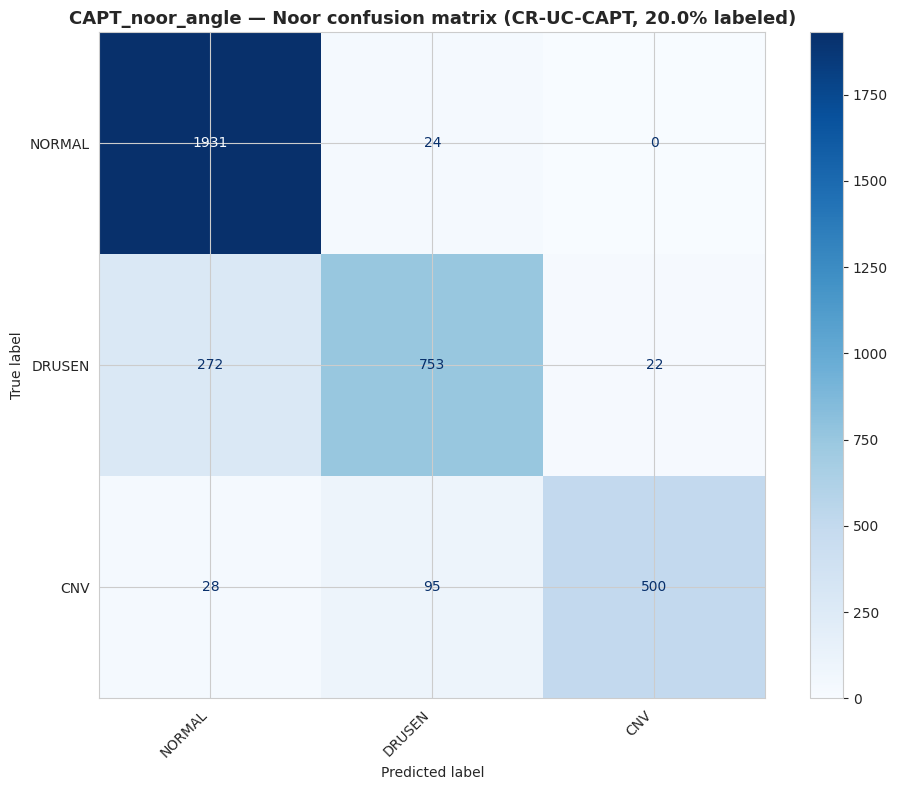


Under-Grading Rate (UGR): DRUSEN/CNV cases predicted NORMAL.
  combined            : 0.1796
  DRUSEN -> NORMAL    : 0.2598
  CNV -> NORMAL       : 0.0449

Confusion error split: 324 detection errors (0.7347) vs. 117 discrimination errors (0.2653) — detection errors dominate.

Per-class precision/recall asymmetry (over- vs. under-represented predictions):
  class     precision   recall      gap  tag
  NORMAL       0.8655   0.9877  -0.1222  absorber
  DRUSEN       0.8635   0.7192   0.1443  donor
  CNV          0.9579   0.8026   0.1553  donor


[ValForCalib]:   0%|          | 0/278 [00:00<?, ?it/s]


  CR-UC-CAPT ABLATION RUN — CAPT_noor_angle
  Dataset      : Noor OCT dataset (NORMAL / DRUSEN / CNV)
  Label budget : 20.00% of the stratified training pool (2135 labeled images)
  Backbone     : EfficientNet-B0, ImageNet-pretrained (~5.3M params)
  Config       : USE_CAPT=True  USE_CR_CAPT=False  USE_UC_CAPT=False
    accuracy = 0.8783, AUC(macro) = 0.9427, f1_macro = 0.8602, UGR = 0.1796

              precision    recall  f1-score   support

      NORMAL     0.9579    0.8026    0.8734       623
      DRUSEN     0.8635    0.7192    0.7848      1047
         CNV     0.8655    0.9877    0.9226      1955

    accuracy                         0.8783      3625
   macro avg     0.8956    0.8365    0.8602      3625
weighted avg     0.8808    0.8783    0.8743      3625


CAPT_noor_angle STAGE 1 evaluation complete.


In [28]:
ckpt = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
ema_model.ema.load_state_dict(ckpt['ema_state_dict'])
print(f"Loaded best EMA checkpoint (step {ckpt['step']}, val_acc={ckpt['val_acc']:.4f}, "
      f"val_auc={ckpt['val_auc']:.4f}, use_capt={ckpt.get('use_capt')}, "
      f"use_cr_capt={ckpt.get('use_cr_capt')}, use_uc_capt={ckpt.get('use_uc_capt')})")
prototype_tracker.prototypes = ckpt['prototypes'].to(DEVICE)

_, _, test_probs, test_targets = evaluate(ema_model.ema, test_loader, split='Test')
test_metrics, test_preds_idx, test_pred_names, test_true_names = compute_metrics(
    test_probs, test_targets,
    split_name=f'{RUN_NAME} — CR-UC-CAPT, USE_CAPT={USE_CAPT}, USE_CR_CAPT={USE_CR_CAPT}, '
               f'USE_UC_CAPT={USE_UC_CAPT}')

f1_per_class = f1_score(test_true_names, test_pred_names, labels=CLASSES,
                         average=None, zero_division=0)
test_metrics['f1_per_class'] = {c: float(f) for c, f in zip(CLASSES, f1_per_class)}
print('\nPer-class F1:')
for c, f in test_metrics['f1_per_class'].items():
    print(f'  {c:8s}: {f:.4f}')

@torch.no_grad()
def pseudo_label_precision_report(eval_model, unlabeled_loader_diag, use_capt,
                                  tau_c_snapshot, cost_snapshot):
    """MODIFIED vs. CAPT.md: uses compute_instance_thresholds for the diagnostic
    mask too, so this report reflects the SAME admission rule actually used
    during training (including Direction 2's per-sample modulation if enabled),
    not a simplified class-only approximation."""
    eval_model.eval()
    all_pred, all_true, all_mask = [], [], []
    for (xw, _, _), y_true in tqdm(unlabeled_loader_diag, desc='[PseudoLabelDiag]',
                                    leave=False, dynamic_ncols=True):
        xw = xw.to(DEVICE, non_blocking=True)
        y_true = y_true.to(DEVICE, non_blocking=True)
        out = eval_model(xw)
        logits, pfeat = out if isinstance(out, tuple) else (out, None)
        probs = F.softmax(logits, dim=-1)
        max_probs, p_targets = torch.max(probs, dim=-1)
        if use_capt:
            tau_instance, _ = compute_instance_thresholds(tau_c_snapshot, p_targets, pfeat)
            m = max_probs.ge(tau_instance).float()
        else:
            m = max_probs.ge(THRESHOLD).float()
        all_pred.append(p_targets.cpu()); all_true.append(y_true.cpu()); all_mask.append(m.cpu())
    all_pred = torch.cat(all_pred); all_true = torch.cat(all_true); all_mask = torch.cat(all_mask)
    admitted = all_mask.bool()
    n_admitted = admitted.sum().item()
    if n_admitted == 0:
        return {'pseudo_label_precision': float('nan'), 'n_admitted': 0, 'coverage': 0.0}
    precision = (all_pred[admitted] == all_true[admitted]).float().mean().item()
    coverage = n_admitted / len(all_true)
    return {'pseudo_label_precision': precision, 'n_admitted': n_admitted, 'coverage': coverage}


_diag_loader = DataLoader(_unlabeled_ds, sampler=SequentialSampler(_unlabeled_ds),
                          batch_size=BATCH_SIZE_LABELED, num_workers=NUM_WORKERS)
_C_final_for_diag = estimate_labeled_confusion(ema_model.ema, labeled_eval_loader) if USE_CR_CAPT else None
_cost_final = compute_clinical_cost_per_pred(_C_final_for_diag) if USE_CR_CAPT else None
_tau_c_final = compute_class_thresholds(cost_per_pred=_cost_final) if USE_CAPT else None
pseudo_diag = pseudo_label_precision_report(ema_model.ema, _diag_loader, USE_CAPT,
                                            _tau_c_final, _cost_final)
test_metrics['pseudo_label_precision'] = pseudo_diag['pseudo_label_precision']
test_metrics['pseudo_label_coverage']  = pseudo_diag['coverage']
print(f"\nPseudo-label precision (diagnostic, true labels used for monitoring ONLY): "
      f"{pseudo_diag['pseudo_label_precision']:.4f}  "
      f"(coverage={pseudo_diag['coverage']:.4f}, n_admitted={pseudo_diag['n_admitted']}/{len(_unlabeled_ds)})")

cm = confusion_matrix(test_true_names, test_pred_names, labels=CLASSES)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES).plot(
    cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'{RUN_NAME} — Noor confusion matrix (CR-UC-CAPT, {TRAIN_RATIO*100:.1f}% labeled)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{RUN_NAME}_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# Post-hoc, zero-retraining confusion-analysis diagnostics — identical to CAPT.md.
# The Under-Grading Rate (UGR) below is EXACTLY the metric kimi.txt's own
# ablation table (Fixed / CAPT / CR-CAPT / UC-CAPT / CR-UC-CAPT) asks for.
# ═════════════════════════════════════════════════════════════════════════════
_i_normal = CLASSES.index('NORMAL')
_i_drusen = CLASSES.index('DRUSEN')
_i_cnv    = CLASSES.index('CNV')

_drusen_total = cm[_i_drusen, :].sum()
_cnv_total = cm[_i_cnv, :].sum()
_disease_total = _drusen_total + _cnv_total

_drusen_missed_as_normal = cm[_i_drusen, _i_normal]
_cnv_missed_as_normal = cm[_i_cnv, _i_normal]

ugr_combined = ((_drusen_missed_as_normal + _cnv_missed_as_normal) / _disease_total
                if _disease_total > 0 else float('nan'))
ugr_drusen = (_drusen_missed_as_normal / _drusen_total) if _drusen_total > 0 else float('nan')
ugr_cnv = (_cnv_missed_as_normal / _cnv_total) if _cnv_total > 0 else float('nan')

test_metrics['under_grading_rate'] = {
    'combined': float(ugr_combined),
    'drusen_missed_as_normal': float(ugr_drusen),
    'cnv_missed_as_normal': float(ugr_cnv),
}
print('\nUnder-Grading Rate (UGR): DRUSEN/CNV cases predicted NORMAL.')
print(f'  combined            : {ugr_combined:.4f}' if _disease_total > 0 else
      '  combined            : nan (no diseased test samples)')
print(f'  DRUSEN -> NORMAL    : {ugr_drusen:.4f}' if _drusen_total > 0 else
      '  DRUSEN -> NORMAL    : nan (zero true DRUSEN test samples)')
print(f'  CNV -> NORMAL       : {ugr_cnv:.4f}' if _cnv_total > 0 else
      '  CNV -> NORMAL       : nan (zero true CNV test samples)')

_n_disease_detection = 0
_n_disease_discrimination = 0
for _i_true, _c_true in enumerate(CLASSES):
    for _i_pred, _c_pred in enumerate(CLASSES):
        if _i_true == _i_pred:
            continue
        _count = int(cm[_i_true, _i_pred])
        if _c_true == 'NORMAL' or _c_pred == 'NORMAL':
            _n_disease_detection += _count
        else:
            _n_disease_discrimination += _count

_n_total_errors = _n_disease_detection + _n_disease_discrimination
_detection_rate = (_n_disease_detection / _n_total_errors) if _n_total_errors > 0 else float('nan')
_discrimination_rate = (_n_disease_discrimination / _n_total_errors) if _n_total_errors > 0 else float('nan')

test_metrics['confusion_error_split'] = {
    'disease_detection_errors': _n_disease_detection,
    'disease_discrimination_errors': _n_disease_discrimination,
    'disease_detection_error_rate': float(_detection_rate),
    'disease_discrimination_error_rate': float(_discrimination_rate),
}
if _n_total_errors > 0:
    _dominant = 'detection' if _n_disease_detection >= _n_disease_discrimination else 'discrimination'
    print(f'\nConfusion error split: {_n_disease_detection} detection errors '
          f'({_detection_rate:.4f}) vs. {_n_disease_discrimination} discrimination errors '
          f'({_discrimination_rate:.4f}) — {_dominant} errors dominate.')
else:
    print('\nConfusion error split: no misclassifications on the test set.')

_precision_per_class = precision_score(test_true_names, test_pred_names,
                                        labels=CLASSES, average=None, zero_division=0)
_recall_per_class = recall_score(test_true_names, test_pred_names,
                                  labels=CLASSES, average=None, zero_division=0)

class_asymmetry = {}
for _c, _p, _r in zip(CLASSES, _precision_per_class, _recall_per_class):
    _gap = float(_p) - float(_r)
    if _gap < -0.05:
        _tag = 'absorber'
    elif _gap > 0.05:
        _tag = 'donor'
    else:
        _tag = 'balanced'
    class_asymmetry[_c] = {
        'precision': float(_p), 'recall': float(_r), 'gap': _gap, 'tag': _tag,
    }
test_metrics['class_asymmetry'] = class_asymmetry

print('\nPer-class precision/recall asymmetry (over- vs. under-represented predictions):')
print(f"  {'class':8s} {'precision':>10s} {'recall':>8s} {'gap':>8s}  tag")
for _c, _v in class_asymmetry.items():
    print(f"  {_c:8s} {_v['precision']:>10.4f} {_v['recall']:>8.4f} {_v['gap']:>8.4f}  {_v['tag']}")

test_metrics['run_config'] = {
    'use_capt': USE_CAPT, 'use_cr_capt': USE_CR_CAPT, 'use_uc_capt': USE_UC_CAPT,
    'beta': BETA, 'gamma': GAMMA,
}

with open(f'{RUN_NAME}_test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

with torch.no_grad():
    _, _, val_probs_for_calib, val_targets_for_calib = evaluate(ema_model.ema, val_loader, split='ValForCalib')
np.savez(f'{RUN_NAME}_logits_for_calibration.npz',
         val_probs=val_probs_for_calib, val_targets=val_targets_for_calib,
         test_probs=test_probs, test_targets=test_targets)

print('\n' + '=' * 74)
print(f'  CR-UC-CAPT ABLATION RUN — {RUN_NAME}')
print('=' * 74)
print(f'  Dataset      : Noor OCT dataset (NORMAL / DRUSEN / CNV)')
print(f'  Label budget : {TRAIN_RATIO*100:.2f}% of the stratified training pool '
      f'({len(labeled_df)} labeled images)')
print(f'  Backbone     : EfficientNet-B0, ImageNet-pretrained (~5.3M params)')
print(f'  Config       : USE_CAPT={USE_CAPT}  USE_CR_CAPT={USE_CR_CAPT}  USE_UC_CAPT={USE_UC_CAPT}')
print(f'    accuracy = {test_metrics["accuracy"]:.4f}, AUC(macro) = {test_metrics["auc_macro"]:.4f}, '
      f'f1_macro = {test_metrics["f1_macro"]:.4f}, UGR = {ugr_combined:.4f}')
print('=' * 74)

print('\n' + classification_report(test_true_names, test_pred_names,
                                   target_names=CLASSES, digits=4))
print(f'\n{RUN_NAME} STAGE 1 evaluation complete.')

## STAGE 2 (optional, skippable) — post-hoc temperature-scaling calibration

Unchanged from `CAPT.md`. No retraining occurs in STAGE 2.

In [29]:
_calib = np.load(f'{RUN_NAME}_logits_for_calibration.npz')
val_probs_c   = _calib['val_probs']
val_targets_c = _calib['val_targets']
test_probs_c  = _calib['test_probs']
test_targets_c = _calib['test_targets']

_EPS = 1e-12
val_logits_approx  = np.log(np.clip(val_probs_c, _EPS, 1.0))
test_logits_approx = np.log(np.clip(test_probs_c, _EPS, 1.0))

val_logits_t  = torch.from_numpy(val_logits_approx).float()
val_targets_t = torch.from_numpy(val_targets_c).long()

T_param = torch.nn.Parameter(torch.ones(1) * 1.0)
T_optimizer = torch.optim.LBFGS([T_param], lr=0.01, max_iter=200)


def _T_nll_closure():
    T_optimizer.zero_grad()
    scaled = val_logits_t / T_param.clamp(min=1e-3)
    loss = F.cross_entropy(scaled, val_targets_t)
    loss.backward()
    return loss


T_optimizer.step(_T_nll_closure)
T_fitted = float(T_param.detach().clamp(min=1e-3).item())

print(f'Fitted temperature T = {T_fitted:.4f}  (T=1.0 means no change from raw softmax)')

test_logits_t   = torch.from_numpy(test_logits_approx).float()
test_probs_scaled  = F.softmax(test_logits_t / T_fitted, dim=-1).numpy()
val_probs_scaled   = F.softmax(val_logits_t / T_fitted, dim=-1).numpy()

np.savez(f'{RUN_NAME}_calibrated_test_probs.npz',
         test_probs_scaled=test_probs_scaled, test_targets=test_targets_c, T=T_fitted)
print('Calibrated test probabilities saved.')

Fitted temperature T = 2.1923  (T=1.0 means no change from raw softmax)
Calibrated test probabilities saved.


ECE (uncalibrated, T=1.0)      : 0.1008
ECE (temperature-scaled, T=2.192) : 0.0615


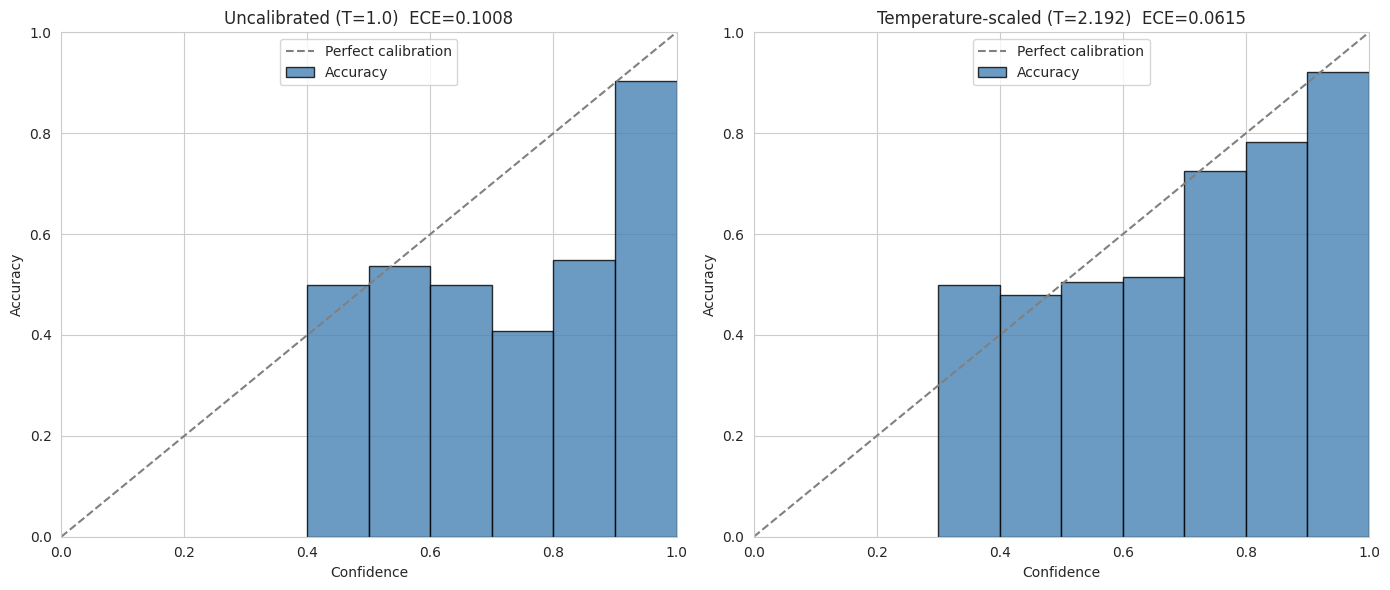


CAPT_noor_angle STAGE 2 (calibration) complete.


In [30]:
def expected_calibration_error(probs, targets, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == targets).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        prop_in_bin = in_bin.mean()
        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin
            bin_stats.append((lo, hi, acc_in_bin, conf_in_bin, prop_in_bin))
        else:
            bin_stats.append((lo, hi, np.nan, np.nan, 0.0))
    return ece, bin_stats


ece_uncalibrated, bins_uncalibrated = expected_calibration_error(test_probs_c, test_targets_c)
ece_calibrated, bins_calibrated = expected_calibration_error(test_probs_scaled, test_targets_c)

print(f'ECE (uncalibrated, T=1.0)      : {ece_uncalibrated:.4f}')
print(f'ECE (temperature-scaled, T={T_fitted:.3f}) : {ece_calibrated:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, bin_stats, title, ece_val in [
    (axes[0], bins_uncalibrated, f'Uncalibrated (T=1.0)  ECE={ece_uncalibrated:.4f}', ece_uncalibrated),
    (axes[1], bins_calibrated, f'Temperature-scaled (T={T_fitted:.3f})  ECE={ece_calibrated:.4f}', ece_calibrated),
]:
    bin_centers = [(lo + hi) / 2 for lo, hi, *_ in bin_stats]
    accs = [a for _, _, a, _, _ in bin_stats]
    ax.bar(bin_centers, accs, width=1.0 / len(bin_stats), edgecolor='black',
           color='steelblue', alpha=0.8, label='Accuracy')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.savefig(f'{RUN_NAME}_reliability_diagram.png', dpi=200, bbox_inches='tight')
plt.show()

with open(f'{RUN_NAME}_calibration_metrics.json', 'w') as f:
    json.dump({'T': T_fitted, 'ece_uncalibrated': ece_uncalibrated,
               'ece_calibrated': ece_calibrated}, f, indent=2)

print(f'\n{RUN_NAME} STAGE 2 (calibration) complete.')

## Required ablation — kimi.txt's 5-row table

Produced from this single file by toggling `USE_CAPT`, `USE_CR_CAPT`, `USE_UC_CAPT` in Cell 1
and re-running end-to-end each time (change `RUN_NAME` per row so outputs don't collide):

| Row | `USE_CAPT` | `USE_CR_CAPT` | `USE_UC_CAPT` | `RUN_NAME` |
|---|---|---|---|---|
| Fixed (0.95) | `False` | `False` | `False` | `'CAPT_v4_noor_fixed'` |
| CAPT (balance only) | `True` | `False` | `False` | `'CAPT_v4_noor_capt'` |
| CR-CAPT (risk only) | `True` | `True` | `False` | `'CAPT_v4_noor_cr'` |
| UC-CAPT (uncertainty only) | `True` | `False` | `True` | `'CAPT_v4_noor_uc'` |
| CR-UC-CAPT (full) | `True` | `True` | `True` | `'CAPT_v4_noor_full'` |

For each row, Cell 16's `test_metrics.json` contains `accuracy`, `f1_macro`,
`under_grading_rate.combined` (UGR), and `auc_macro` — exactly the four columns kimi.txt's
table asks for. As with the rest of this project's ablations, report these as **single-seed**
numbers unless you have actually run multiple seeds per row — do not present single-run deltas
as if they were statistically established without saying so explicitly.

**Honest expectation, not a guarantee:** kimi.txt's table shows CR-UC-CAPT (full) winning on
every column. That is the *hypothesis* this ablation tests, not a known result. If any
individual row (e.g. UC-CAPT alone) does not improve on CAPT-only, or if the full combination
does not beat either individual direction, report that plainly — a partial or negative result
here is informative and should not be omitted from the paper.

## Positioning: what CR-UC-CAPT actually is, stated conservatively

`kimi.txt` frames this combination as reaching "8/10" novelty and describes the paper's claim
as introducing *"the first cost-sensitive, uncertainty-conditional pseudo-label admission
framework for medical SSL."* That framing is **not adopted as-is here** — it should be checked
against the literature before being used in any actual paper draft, for the same reason this
project's other CAPT variants (`capt_v2.md`, `CAPT_v3.md`) have consistently discounted
similarly strong novelty claims pending a real literature check.

**What Direction 1 (CR-CAPT) actually is.** Cost-sensitive thresholds derived from an
asymmetric cost matrix and an estimated confusion/error-rate structure are a long-established
idea in cost-sensitive learning generally (Elkan, 2001, and much subsequent work on
cost-sensitive classification thresholds) and have been applied to class-imbalanced and
noisy-label settings specifically. Applying this idea to a semi-supervised pseudo-label
*admission* threshold (rather than a final classification decision) is a more specific
combination, but the core mechanism — cost-weighted confusion informing a decision threshold —
is not new in kind.

**What Direction 2 (UC-CAPT) actually is.** Using distance to a class prototype in a learned
feature space as an uncertainty proxy is used in several existing method families: prototype
networks for few-shot/semi-supervised learning, open-set recognition (where distance-to-nearest-
prototype is a standard novelty/uncertainty score), and some pseudo-label confidence-calibration
work. The specific choice here — normalize per-batch, gather only the predicted class's
distance, and multiply (not add) into the class-level threshold — is this notebook's own
assembly, but the underlying signal (prototype distance as an uncertainty proxy) is
well-established elsewhere.

**What the combination is.** Multiplying a class-level, risk-and-balance-aware threshold by a
per-sample uncertainty factor, in one admission rule, for a 3-class medical OCT task at extreme
label scarcity — this specific assembly, applied to this specific problem, is plausibly novel
as a combination, in the same sense `CAPT_v3.md`'s FA-CAPT was assessed: a combination of
existing idea classes (cost-sensitive thresholds; prototype-distance uncertainty; the original
CAPT balance term) applied to a new setting, not a structurally new mechanism class on its own.

**Recommended claim for an actual paper draft, more defensible than kimi.txt's framing:**
*"We combine three existing threshold-adaptation signals — class-prevalence balance,
asymmetric clinical cost, and prototype-distance uncertainty — into a single instance-level
pseudo-label admission rule, and show [via the Cell 20 ablation] whether and how much each
component contributes in a 3-class, extreme-label-scarcity medical OCT setting."* This claim
is checkable, does not overclaim priority over cost-sensitive learning or prototype-based
uncertainty estimation as idea classes, and is falsifiable by the ablation table itself — if
CR-UC-CAPT does not outperform its individual components, the paper should report that,
exactly as `CAPT_v3.md`'s Cell 20e instructs for its own ablation.

**Before finalizing any related-work section for this file:** verify, do not assume, whether
any of Guo & Li (ICML 2022), FreeMatch, FlexMatch, or the cost-sensitive-SSL literature already
combine a cost matrix with instance-level (not just class-level) thresholding — that specific
combination is the actual claim being made here, and it must be checked against primary sources
before being asserted as novel, exactly as `CAPT_v3.md`'s Cell 21 flagged for its own unverified
CAPR/CLCP-MT/GTPL row.